# Agent 手册

## Agent 的四个组成部分

可以用下面的式子帮助理解：

> **Agent = LLM + 规划 + 记忆 + 工具。**

| 组成部分 | 负责什么 | 旅行规划中的例子 |
| --- | --- | --- |
| LLM | 理解目标、选择下一步、组织答案 | 理解预算、天数和旅行偏好 |
| Planning，规划 | 分解任务，安排执行顺序和依赖 | 先查交通与住宿，再核算总价 |
| Memory，记忆 | 保存当前状态和可复用的信息 | 记住用户偏好，以及已经查到的报价 |
| Tools，工具 | 与真实数据和外部系统交互 | 搜索、调用订票 API、计算费用、生成文件 |

## 四层架构：请求在系统里怎么走

从实现角度看，可以把 Agent 划分为感知、认知、执行和记忆四层。

| 层次 | 输入与输出 | 需要解决的问题 |
| --- | --- | --- |
| 感知层 | 用户输入 → 可处理的需求 | 用户想做什么，约束有哪些，缺什么信息 |
| 认知层 | 需求与当前状态 → 下一步动作 | 是否需要工具，使用哪个工具，是否继续 |
| 执行层 | 工具名和参数 → 工具结果 | 校验参数、调用服务、处理失败 |
| 记忆层 | 对话和结果 → 可复用状态 | 当前任务记住什么，下次任务还能使用什么 |

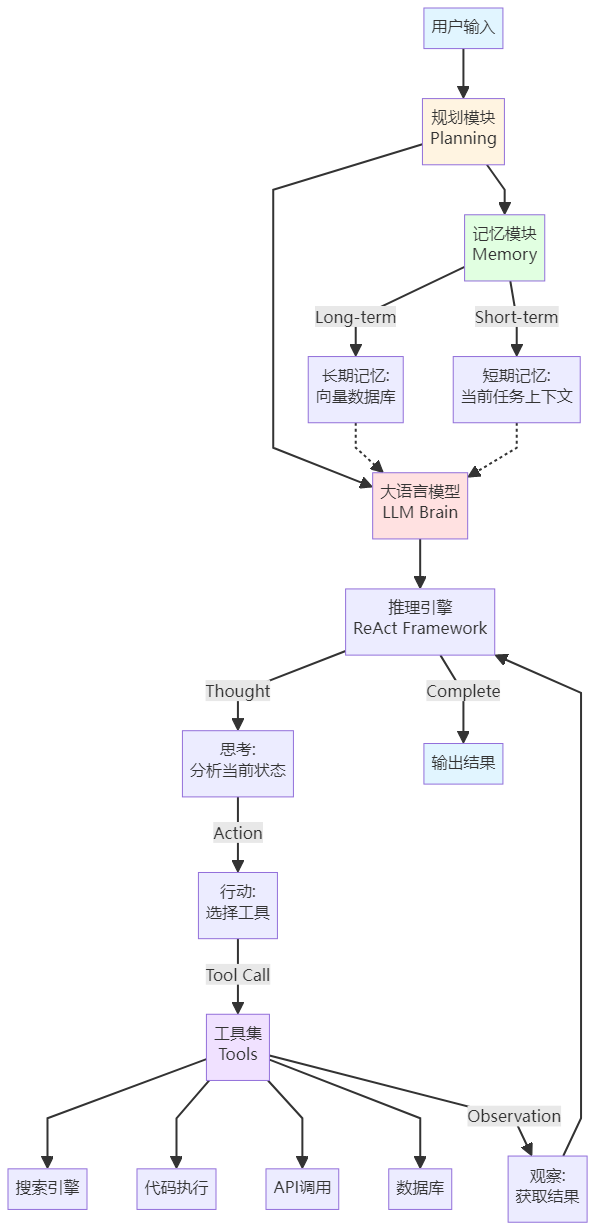

记忆层贯穿整个过程。执行层得到的结果会写回状态，认知层再读取这些结果，决定接下来怎么做。系统由此形成反馈循环，而不是一次调用就结束。

## LLM 负责决策，程序负责执行

模型在 Agent 中主要做四件事：理解意图、拆解任务、选择工具、根据结果组织回答。

## 规划：把目标拆成有顺序的任务

“准备一场技术分享会”是目标，不是可以直接执行的一条指令。需要进一步明确：

1. 确定主题和目标听众。
2. 搜索资料和案例。
3. 设计大纲。
4. 准备演示 Demo。
5. 编写演讲稿并检查内容。

规划模块要说明每一步做什么、需要哪些输入、什么结果算完成，以及依赖哪些步骤。否则，Agent 很容易反复搜索，却迟迟交付不了成果。

规划有两种主要方式，也可以结合使用：

| 方式 | 怎么执行 | 适合什么任务 |
| --- | --- | --- |
| ReAct | 每次根据当前结果决定下一步 | 探索性任务，中途可能遇到未知情况 |
| Plan-and-Execute | 先生成计划，再调度执行 | 步骤比较明确，可以列出依赖关系 |
| 两者结合 | 先有粗计划，执行时局部调整 | 既有固定流程，又有不确定环节的任务 |

先计划并不意味着执行时永远不能修改计划。实际系统通常还需要“重新规划”，处理数据缺失、工具失败或需求变化。

## ReAct：决定、行动、观察，再决定

ReAct 是 Reasoning 与 Acting 的结合。一次循环可以拆成三个部分：

- **决策：** 当前还缺什么信息，下一步应该做什么。
- **行动：** 调用某个工具，并给出参数。
- **观察：** 接收工具实际返回的结果。

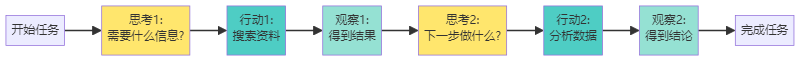

工具结果会改变下一步动作。例如查酒店时发现预算不够，Agent 可以降低酒店档次或调整日期，而不是继续生成一个超预算的方案。

原文经常用 `Thought → Action → Observation` 展示过程。学习时可以把它理解成“决策说明 → 工具请求 → 工具结果”。实现中应记录可检查的动作、参数和证据，不需要依赖模型公开完整的内部推理。

## ReAct 什么时候结束

Agent 不应因为“还能继续调用工具”就一直运行。它至少需要三类停止条件：

| 情况 | 应当怎么处理 |
| --- | --- |
| 已获得完成任务所需的信息 | 组织最终回答，返回结果 |
| 缺少必要信息或遇到无法恢复的错误 | 说明缺少什么，追问或转交处理 |
| 达到次数、时间或费用上限 | 停止执行，返回当前进展和限制 |

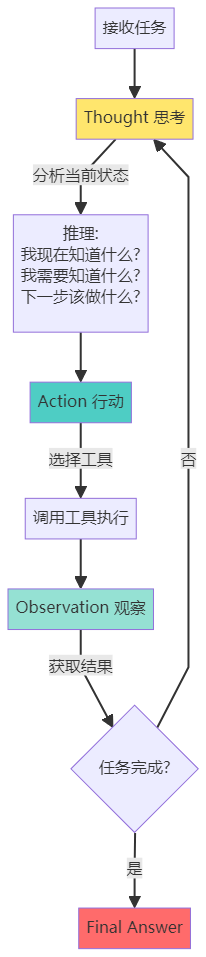

“结束”是运行时的一部分。只在提示词里写“请在五步内完成”，不能替代程序里的计数器和超时控制。

## Plan-and-Execute：先列计划，再按依赖执行

原文用“分析市场趋势”说明先计划后执行：搜索报告、提取数据、识别参与者、汇总结论。

计划可以保存为结构化数据：

~~~python
plan = [
    {"id": "research", "task": "收集市场报告", "depends_on": []},
    {"id": "products", "task": "收集主要产品资料", "depends_on": []},
    {"id": "analysis", "task": "分析规模和竞争格局",
     "depends_on": ["research", "products"]},
    {"id": "report", "task": "生成报告", "depends_on": ["analysis"]},
]
~~~

前两个任务互不依赖，可以并行；后两个任务需要等待前面的结果。

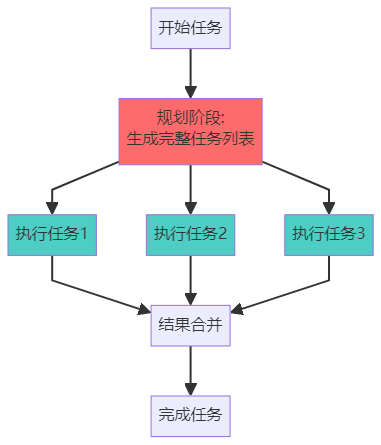

计划里的 `depends_on` 是调度约束，不是给读者看的注释。执行器要检查依赖是否成功，并把相应结果传给后续任务。计划本身也需要校验：任务 ID 不能重复，不能引用不存在的任务，更不能形成循环依赖。

## 执行计划时，还要保存任务状态

列出任务之后，需要知道“哪些已经完成”。可以给每个任务维护以下状态：

~~~text
pending → running → succeeded
                  ↘ failed
~~~

只有依赖任务处于 `succeeded`，后续任务才能开始。失败后，可以重试当前步骤、修改计划或终止整个任务。

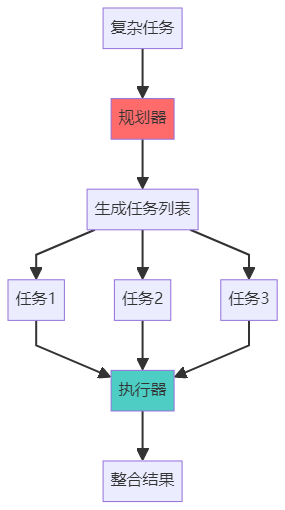

假设报告写到一半时搜索服务出错，保存状态可以让系统从失败步骤恢复。直接重新执行全部任务，会浪费已经完成的工作，也可能重复产生外部操作。

## CoT 与 Self-Ask：两种帮助拆解问题的方式

**CoT（Chain of Thought）**强调把复杂问题分解成中间步骤。它本身不要求调用外部工具，因此不能仅凭“模型会分步分析”就判断系统已经具备 Agent 执行能力。

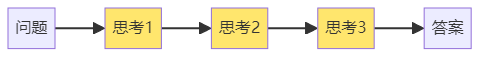

**Self-Ask**先提出能帮助解决主问题的子问题，再分别回答。例如比较两款手机的屏幕尺寸，可以先查 A 的尺寸，再查 B 的尺寸，最后计算差值。

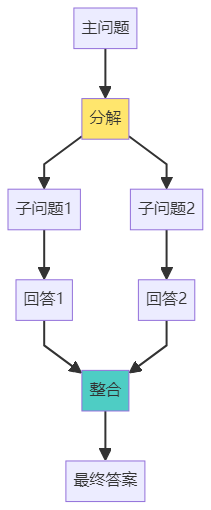

两者都帮助组织任务，但“增加步骤”不必然降低 token 开销。是否更便宜、更准确，需要在相同任务上实际比较。

## 理解 Agent 的三个视角

Agent 可以从三个互补的角度理解：

| 视角 | 应该关注什么 | 对应的设计问题 |
| --- | --- | --- |
| 把它看作员工 | 职责、交付物、边界 | 输入是什么，输出是什么，什么时候交给人 |
| 把它看作循环系统 | 状态、反馈、终止 | 为什么继续，为什么停止，失败如何恢复 |
| 把它看作模型与工具的组合 | 模型能力与工具能力 | 哪些事情靠模型，哪些必须查数据或执行程序 |

例如“生成销售报告”：员工视角规定报告需要哪些部分；循环视角管理搜集、分析和修改；工具视角决定用数据库取数、Python 计算、文件工具保存报告。

三个视角放在一起，才能从“模型回答得不错”走到“系统能交付可靠结果”。

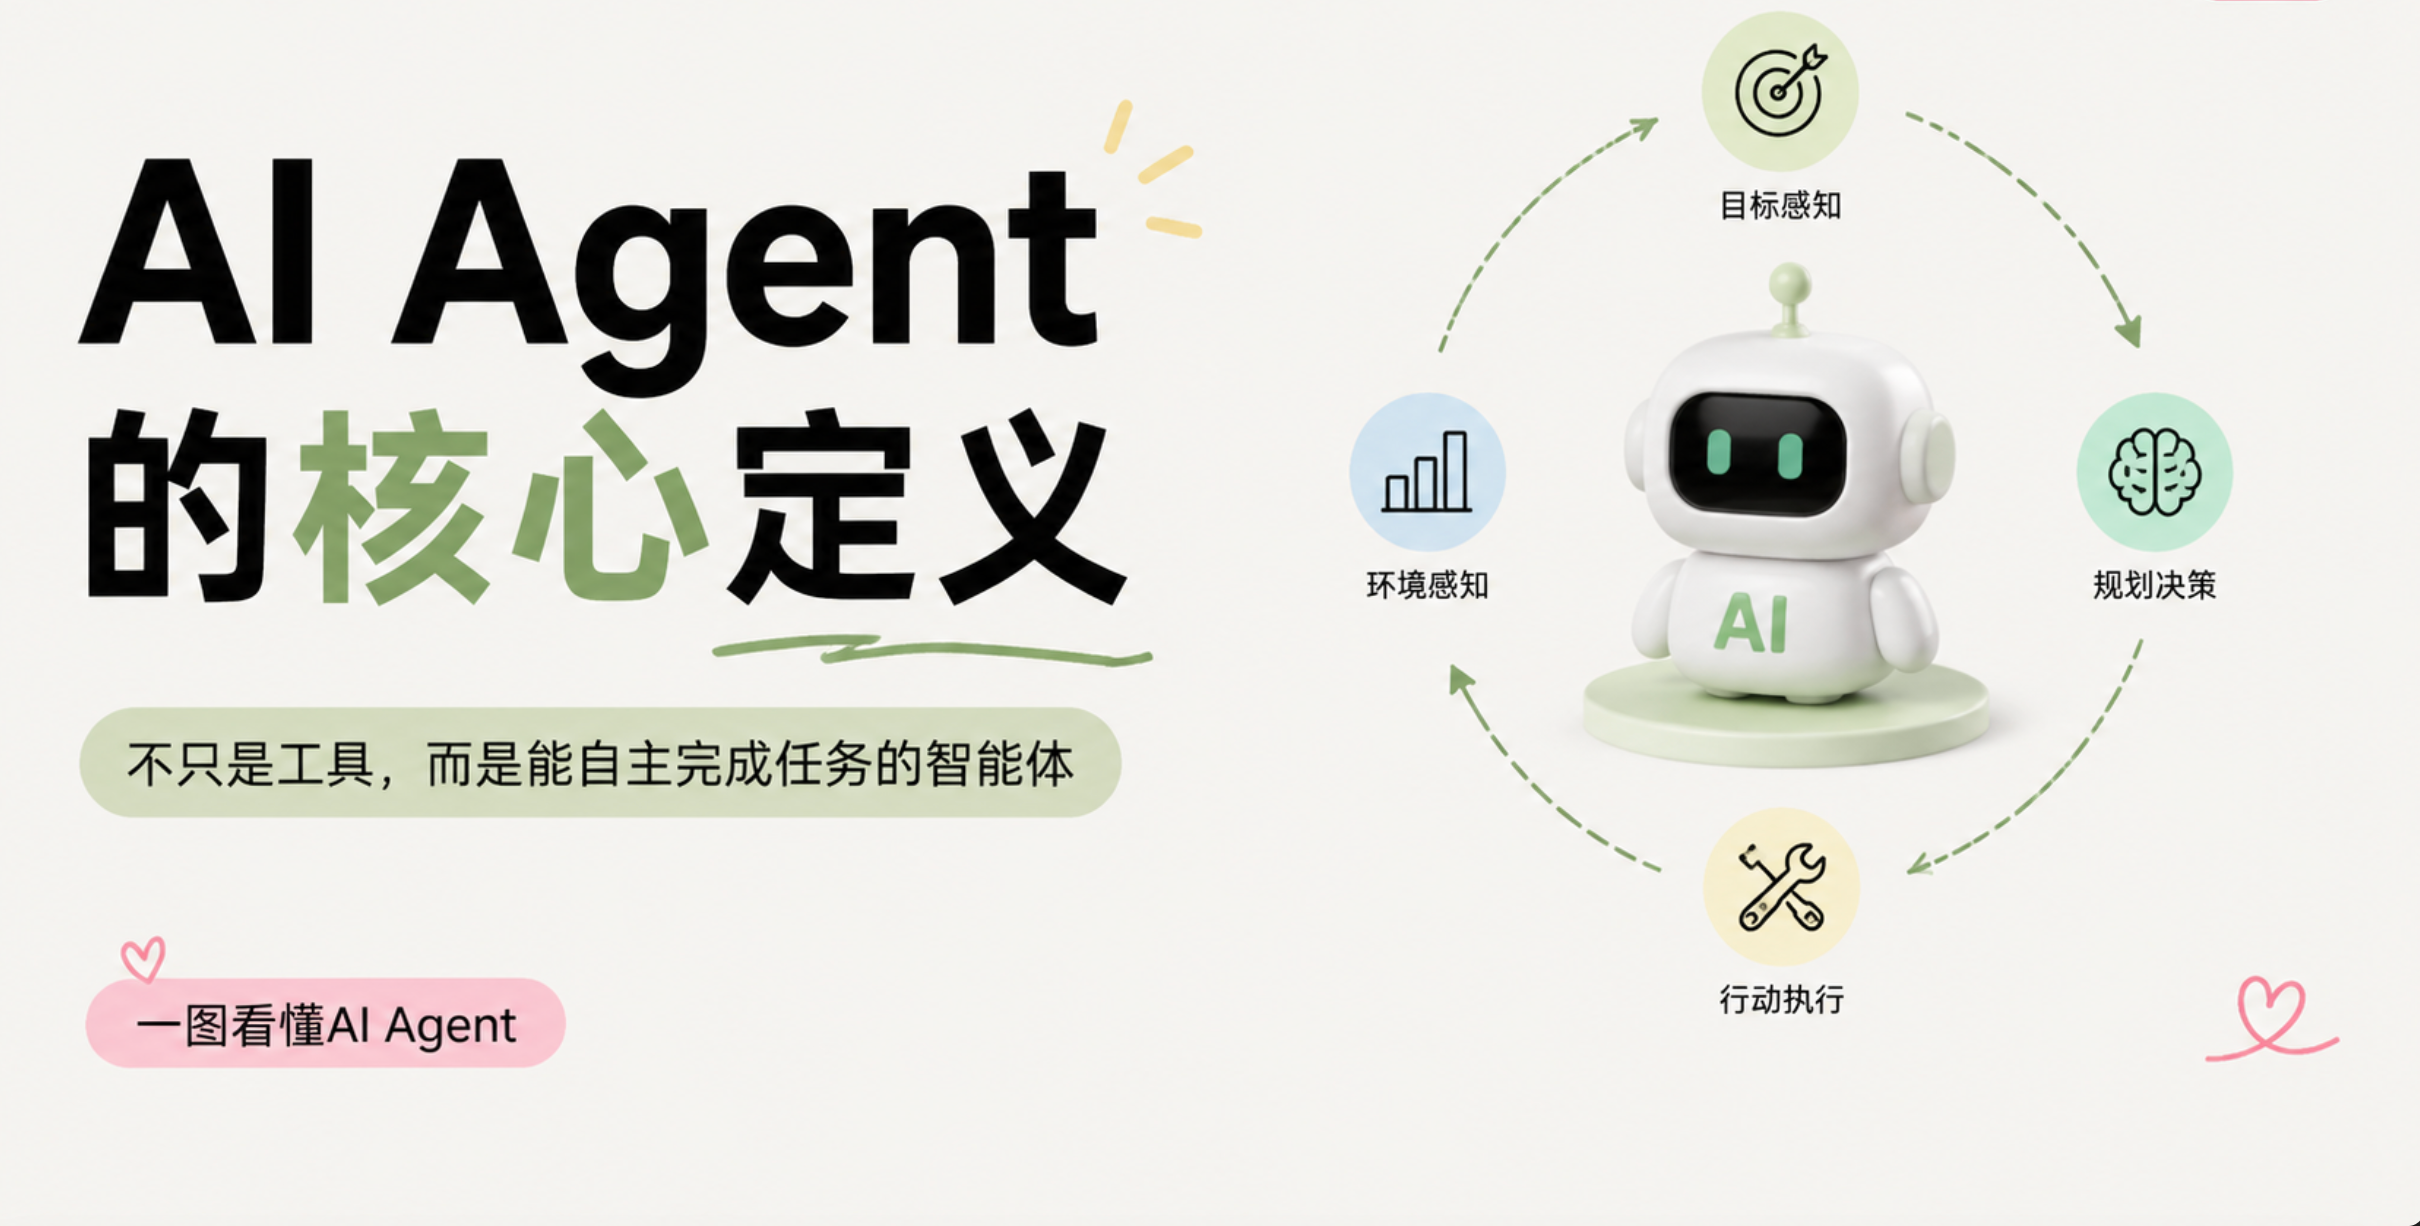

## 短期记忆：保存当前任务的状态

用户先说“帮我查询订单 ORD123456”，下一句只问“什么时候能到”。第二句话没有重复订单号，系统必须利用前面的上下文。

短期记忆通常包含：

- 当前对话的最近消息。
- 用户已经明确的目标和约束。
- 正在处理的任务、意图和参数。
- 已完成步骤与工具返回结果。

~~~python
state = {
    "goal": "查询订单物流",
    "current_order_id": "ORD123456",
    "messages": [],
    "observations": [],
    "status": "running",
}
~~~

**模型能记住，是因为应用把相关状态重新提供给它。** 对话历史通常不会自动写进模型参数。

不同用户、不同会话的状态应分别保存。一个全局列表装下所有人的历史，会把上下文混在一起。

## 长期记忆：跨任务保存可复用信息

短期记忆关注“这次正在做什么”，长期记忆关注“以后还用得上的信息”。例如用户偏好、长期有效的约束、经过验证的经验和领域知识。

一种常见实现是使用向量数据库：先把内容向量化保存，任务开始时再检索相关记忆，放入上下文。

~~~text
新任务：为用户推荐餐厅
  → 查找相关偏好
  → 得到“偏好川菜，预算 500 元”
  → 结合本次地点、日期等条件
  → 查询符合要求的餐厅
~~~

这与 RAG 的思路相通：都在回答或执行之前检索外部信息。区别在于用途和生命周期；用户偏好不一定适合和公共知识文档放在同一个集合中。

并非所有长期记忆都需要向量库。用户 ID、预算、过期时间等确定字段，用关系数据库或键值存储往往更直接。

## 记忆要筛选、压缩，也要过期

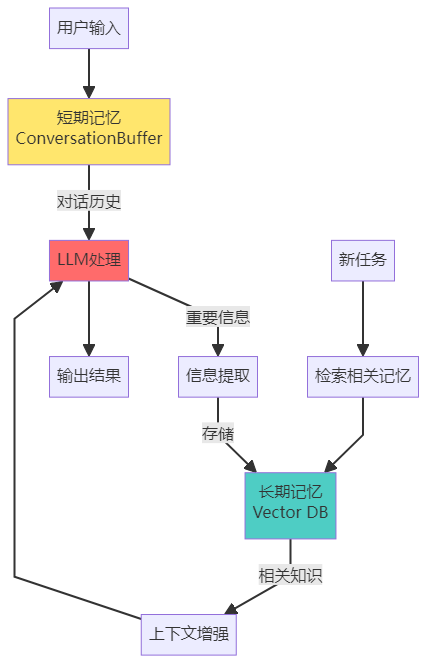

记忆管理可以从三个方面入手。

**重要性筛选：** 优先保存稳定偏好、明确约束和经过验证的经验，而不是每一句闲聊。模型可以辅助打分，但写入规则不能只依赖一个随口生成的数字。

**分层保存：** 最近几轮保留原文，较早内容整理成摘要，更久的内容按需检索。摘要要保留任务目标、关键参数和未解决事项。

**时效性管理：** 为信息保存时间戳、来源和有效期。临时报价与长期偏好应该使用不同的过期策略。

~~~python
from datetime import datetime, timedelta, timezone

now = datetime.now(timezone.utc)
memory_item = {
    "user_id": "u_001",
    "content": "本次旅行预算为 5000 元",
    "source": "用户在当前会话中明确提供",
    "created_at": now,
    "expires_at": now + timedelta(days=7),
}
~~~

这里的 7 天只是演示值。更重要的是把“本次旅行预算”限制在相关任务内，不能自动变成用户永久不变的偏好。

## 工具：模型与外部系统的接口

一个工具不只是一个函数名。它应当同时说明：

| 要素 | 作用 |
| --- | --- |
| 名称 | 让模型区分不同能力 |
| 描述 | 说明何时使用、何时不使用 |
| 参数结构 | 约束字段、类型和必填项 |
| 执行函数 | 真正访问 API、数据库或本地计算 |
| 返回结构 | 区分成功、失败、结果与错误原因 |

以查询订单为例：

~~~json
{
  "name": "query_order",
  "description": "查询当前登录用户的一笔订单；需要明确订单号。",
  "parameters": {
    "type": "object",
    "properties": {
      "order_id": {"type": "string"}
    },
    "required": ["order_id"],
    "additionalProperties": false
  }
}
~~~

登录用户身份由服务端提供，不能让模型随意填入任意用户 ID。工具描述帮助模型选择，服务端校验负责真正执行规则。

## 先写一个能看懂的计算工具

原文用计算器说明工具结构，并提醒实际项目不要直接对模型输入使用 `eval`。这里把接口改成明确的操作和两个数字：

~~~python
import math
import operator

OPERATIONS = {
    "add": operator.add,
    "subtract": operator.sub,
    "multiply": operator.mul,
    "divide": operator.truediv,
}

def calculate(operation, a, b):
    if operation not in OPERATIONS:
        return {"ok": False, "error": "unsupported_operation"}
    if any(type(x) not in (int, float) for x in (a, b)):
        return {"ok": False, "error": "invalid_number"}
    try:
        if not all(math.isfinite(x) for x in (a, b)):
            return {"ok": False, "error": "invalid_number"}
        value = OPERATIONS[operation](a, b)
        if not math.isfinite(value):
            return {"ok": False, "error": "out_of_range"}
    except ZeroDivisionError:
        return {"ok": False, "error": "division_by_zero"}
    except OverflowError:
        return {"ok": False, "error": "out_of_range"}
    return {"ok": True, "data": value}

print(calculate("multiply", 12, 8))  # {'ok': True, 'data': 96}
~~~

`OPERATIONS` 是允许使用的操作列表。模型只能从这些操作里选择，不能把任意 Python 程序当作计算表达式执行。

返回 `ok` 和 `error`，是为了让执行器明确区分“计算结果为 0”和“计算失败”。

## 搜索、API、数据库与代码执行工具

原文的四类工具可以按实际职责理解：

| 工具 | 负责什么 | 返回值最好包含什么 |
| --- | --- | --- |
| 搜索 | 查找外部资料、核对事实 | 内容、来源 URL、获取时间 |
| API | 查询天气、物流等业务状态 | 结构化字段、状态码或错误类型 |
| 数据库 | 获取系统中的业务记录 | 受权限约束的查询结果 |
| 代码执行 | 计算、数据处理、生成图表 | 输出、文件位置、错误和资源使用情况 |

数据库工具不一定要接受整条 SQL。业务明确时，“查询订单”这种窄接口更容易控制：

~~~python
def query_order(conn, order_id, user_id):
    row = conn.execute(
        "SELECT status, total FROM orders "
        "WHERE order_id = ? AND user_id = ?",
        (order_id, user_id),
    ).fetchone()
    if row is None:
        return {"ok": False, "error": "order_not_found"}
    return {"ok": True, "data": {"status": row[0], "total": row[1]}}
~~~

占位符 `?` 把 SQL 结构和用户数据分开；`user_id` 条件限制了查询范围。

代码执行工具需要隔离环境、执行时间和资源限制。仅使用 `exec` 或启动一个子进程，并不会自动获得这些隔离能力。

## 把一次工具调用接成一个 Agent 循环

知道工具怎么写之后，再看执行器做什么。下面是框架无关的最小骨架，`decide` 由调用方提供；在真实 Agent 中，它负责调用模型并解析结构化决策。

~~~python
def run_agent(task, decide, tools, max_steps=5):
    state = {"task": task, "observations": []}

    for _ in range(max_steps):
        action = decide(state)

        if action.get("type") == "finish":
            return {"status": "completed", "answer": action["answer"]}

        if action.get("type") != "tool_call":
            return {"status": "failed", "error": "invalid_action"}

        name = action.get("name")
        arguments = action.get("arguments")
        if name not in tools or not isinstance(arguments, dict):
            return {"status": "failed", "error": "invalid_tool_call"}

        # tools 中只放已经负责参数校验和错误处理的工具。
        result = tools[name](**arguments)
        state["observations"].append({
            "tool": name,
            "arguments": arguments,
            "result": result,
        })

    return {"status": "stopped", "reason": "step_limit", "state": state}
~~~

一次循环完成四件事：读取状态、获得决策、调用工具、把结果写回状态。下一轮的 `decide` 因此能看到前一轮的结果。

这段代码只展示主循环。模型返回格式校验、工具超时、权限和费用统计，需要由实际运行时补上；后面分别讲这些问题。

## 不调用模型，也能先验证循环是否理解正确

为了看清控制流，可以临时用一个固定决策函数模拟模型：

~~~python
def demo_decide(state):
    if not state["observations"]:
        return {
            "type": "tool_call",
            "name": "calculate",
            "arguments": {"operation": "multiply", "a": 12, "b": 8},
        }

    result = state["observations"][-1]["result"]
    return {
        "type": "finish",
        "answer": f"12 × 8 = {result['data']}",
    }

result = run_agent(
    "计算 12 × 8",
    decide=demo_decide,
    tools={"calculate": calculate},
)
print(result)
# {'status': 'completed', 'answer': '12 × 8 = 96'}
~~~

第一次调用工具，第二次根据观察结果结束。这里没有真实 LLM，数字也不是模型猜出来的；这个小例子用来确认“决策与执行分工”和“结果如何反馈”两个关键点。

## 为什么 Demo 能跑，真实任务却容易失败

前面的执行循环很短，但真实任务不只会走成功路径。搜索结果可能无关，模型可能重复调用工具，服务可能超时，历史消息也会越来越长。

这几类问题是相互影响的：工具失败会增加重试次数，重试会增加上下文，上下文变长又会增加延迟和费用。因此，Agent 的运行时需要同时管理**进度、错误、上下文和预算**。

| 常见问题 | 能观察到的现象 | 优先处理的位置 |
| --- | --- | --- |
| 无限循环 | 反复搜索，没有新的结论 | 执行循环和终止条件 |
| 工具选错 | 用搜索做计算，或把查订单交给通用问答 | 工具描述、路由和参数校验 |
| 上下文溢出 | 历史越来越长，调用变慢或报错 | 上下文构建和记忆管理 |
| 错误恢复失败 | 一次超时导致整个任务中断 | 工具执行器和任务状态 |
| 成本失控 | 一个简单任务调用模型很多次 | 每步用量统计和预算控制 |

## 避免无限循环：既限制次数，也判断进展

最容易实现的限制是 `max_steps`。还可以限制总耗时、模型调用次数、工具调用次数和 token 用量。次数上限控制“最多做多少次”，进展检查控制“继续做是否还有意义”。

例如连续三次查询相同关键词，得到相同结果，就值得暂停。但“连续使用同一个工具”不等于没有进展：分页读取第 1、2、3 页，虽然工具相同，却在获取不同数据。

可以先比较工具名、参数和有效结果：

~~~python
import json

def repeated_without_progress(observations, window=3):
    recent = observations[-window:]
    if len(recent) < window:
        return False

    fingerprints = [
        json.dumps(
            {
                "tool": item["tool"],
                "arguments": item["arguments"],
                "result": item["result"],
            },
            ensure_ascii=False,
            sort_keys=True,
        )
        for item in recent
    ]
    return len(set(fingerprints)) == 1
~~~

这里假设观察结果可以转换为 JSON。实际结果若包含“请求时间”“请求 ID”等每次变化的字段，应先提取业务内容再比较。

这个函数只能发现一种简单的停滞。换几个近义关键词却始终得不到新证据，还需要结合“已完成哪些子任务、还缺什么信息”判断。

时间限制也要真正落实到调用层。只在循环开头检查时间，无法中断一个一直阻塞的网络请求；HTTP 客户端本身也需要设置超时。

## 工具选错，先检查工具说明是否清楚

假设有两个工具，一个描述是“查询”，另一个也是“查询”。模型无法知道哪个查订单，哪个查天气。工具越多，这种歧义越明显。

工具说明可以统一写成“用途、输入、使用条件、返回结果”四部分：

~~~text
工具名：query_order
用途：查询当前登录用户一笔订单的状态与物流。
输入：order_id，例如 ORD123456。
使用条件：用户要查询已有订单，并且已经提供订单号。
缺少参数：先询问订单号，不猜测。
返回结果：订单状态、物流进度，或明确的错误类型。
~~~

再添加几组短例子，帮助模型区分相近工具：

| 用户请求 | 合适的处理方式 |
| --- | --- |
| “12 件，每件 8 元，一共多少？” | 调用计算工具 |
| “北京明天会下雨吗？” | 确认地点和日期，调用天气工具 |
| “ORD123456 到哪了？” | 调用订单查询工具 |
| “退款规则是什么？” | 检索知识库中的规则 |
| “帮我退掉这笔订单” | 收集订单信息，进入退款业务流程 |

工具很多时，可以先按业务域筛选，再把相关工具交给模型。客服任务通常不需要同时看到绘图、代码部署和报表生成工具。

动态加载减少了干扰和工具描述占用的上下文，但也要保留补选机制。最初没有选中某个工具，不应导致后面永远无法使用它。

## 上下文管理：保存任务需要的信息

一次模型调用使用的上下文，不只是用户最后一句话。

~~~text
系统指令
+ 工具定义
+ 当前用户请求
+ 最近对话
+ 任务状态与历史摘要
+ 检索内容与工具结果
+ 为输出预留的空间
≤ 当前模型允许的上下文长度
~~~

上下文管理的关键是“留下什么”。用户明确的预算、订单号、尚未完成的步骤，比已经重复三次的搜索摘要更重要。

| 信息类型 | 处理方式 |
| --- | --- |
| 当前目标、约束、待办事项 | 保留为结构化状态 |
| 最近几轮对话 | 尽量保留原文 |
| 较早的对话 | 摘要后保留，必要时回查原文 |
| 很长的工具结果 | 提取相关片段，保存完整结果的位置 |
| 外部知识 | 按当前问题检索，不一次塞入全部文档 |
| 工具说明 | 只加载本次任务需要的部分 |

摘要可能遗漏细节，因此订单号、金额、日期等字段最好单独保存。不能只留一句“用户讨论了订单”，然后把真正要查的订单号丢掉。

统计 token 时应使用对应模型的 tokenizer 或服务返回的用量。`len(text.split())` 统计的是按空白分隔的片段，对中文尤其不能当成 token 数量。

## 错误处理：先分清错误能不能重试

错误处理的第一步不是“捕获所有异常后再试一次”，而是区分错误类型。

| 错误 | 例子 | 处理方式 |
| --- | --- | --- |
| 临时服务错误 | 网络超时、短暂限流 | 有上限地重试，逐步延长间隔 |
| 参数错误 | 日期格式不对、缺少订单号 | 修正参数或追问用户 |
| 权限错误 | 当前用户无权访问订单 | 返回权限限制，不能换身份重试 |
| 业务失败 | 订单已关闭，不能退款 | 解释业务状态，提供后续选择 |
| 输出格式错误 | 模型返回了不符合约定的 JSON | 校验并要求有限次数的修正 |

下面的例子只针对可以安全重复执行的查询操作：

~~~python
import time

def retry_read(call, attempts=3, sleep=time.sleep):
    if attempts < 1:
        raise ValueError("attempts 必须至少为 1")

    for attempt in range(attempts):
        try:
            return {"ok": True, "data": call()}
        except (TimeoutError, ConnectionError) as exc:
            if attempt == attempts - 1:
                return {"ok": False, "error": type(exc).__name__}
            sleep(min(2 ** attempt, 8))
~~~

`attempts=3` 表示最多调用三次，等待间隔依次为 1 秒、2 秒。真实项目通常还会加入随机抖动，避免许多请求在同一时刻一起重试，并遵守服务返回的 `Retry-After`。

不同 SDK 有自己的异常类型，需要适配。重试次数也必须计入整个任务的时间和费用预算。

创建订单、付款等写操作不能直接套用这个例子。请求超时不代表服务端没有完成操作，应通过幂等键或状态查询避免重复提交。

## 降级与健康检查：知道自己现在能做什么

降级是保留仍然可用的能力。例如搜索服务不可用时，先展示已有且注明时间的资料；知识库失败时，可以解释通用概念。

但查询“我的订单今天到哪里了”时，模型的常识无法代替物流接口。此时应明确说明未查到实时状态，并保留订单号以便重试。

可以把工具结果统一为：

~~~json
{
  "ok": false,
  "error": {
    "code": "service_timeout",
    "retryable": true,
    "message": "订单服务暂时没有响应"
  }
}
~~~

健康检查用于尽早发现依赖不可用，例如模型接口是否可达、数据库连接是否正常、工具配置是否缺失。它不能保证某笔具体业务一定成功，但能避免明知服务故障还不断发起相同调用。

连续失败时，可以暂时停止调用该服务，过一段时间再探测。这种做法通常称为熔断。任务本身应保存当前状态，恢复后从失败的步骤继续。

## 成本：按一次完整任务计算

一个 Agent 任务会多次调用模型，而且后一轮常常带着前几轮的历史。只看“一次请求多少钱”，容易低估实际成本。

输入和输出应分别计算：

~~~python
def estimate_cost(input_tokens, output_tokens,
                  input_price_per_million, output_price_per_million):
    return (
        input_tokens / 1_000_000 * input_price_per_million
        + output_tokens / 1_000_000 * output_price_per_million
    )

# 假设输入每百万 token 为 2 元，输出为 8 元，仅用于演示计算。
cost = estimate_cost(20_000, 5_000, 2, 8)
print(f"{cost:.2f} 元")  # 0.08 元
~~~

这个例子假设十轮合计使用 20,000 个输入 token、5,000 个输出 token。真实用量要逐次累计；历史不断增长时，每轮输入未必保持相同。

模型费用之外，还可能有搜索服务、向量数据库、代码运行和存储费用。分析业务是否划算时，更有用的指标是**每个成功完成的任务花了多少钱**。

成本优化可以从三个方向做：

- 简单分类、格式整理使用成本较低的模型；复杂规划和异常处理使用能力更强的模型。
- 在每一步执行前检查剩余预算，预留可能的输出费用，执行后记录实际费用。
- 用任务成功率验证优化效果。价格低但反复失败、需要大量重试的模型，总成本可能更高。

并发任务共享预算时，预算检查和额度预留需要原子操作；否则多个任务可能同时判断“余额足够”。

## 缓存：结果相同，使用条件也必须相同

缓存可以避免重复调用，但缓存键不能只保存用户原话。

“北京明天天气”在两天里指向不同的日期；“我的订单”对两个用户指向不同的数据。直接用一句话的哈希值做键，会把不同条件混在一起。

一个天气查询的缓存键可以包含：

~~~python
cache_key = (
    "weather",
    "provider_v1",
    "北京",
    "2026-09-17",   # 把“明天”转换为确定日期
)
~~~

带有用户数据的查询还应包含用户或租户范围。价格、库存、天气等数据需要有效期，业务状态变化后可能需要主动失效。

工具结果缓存、检索缓存和最终回答缓存是不同层次。工具结果通常更容易复用；最终回答可能混入用户偏好和对话上下文，复用条件更严格。

错误结果也不能无限保存。暂时超时不代表这个查询以后都应该返回失败。

## 批处理与并行：解决的不是同一个问题

**批处理**把多个样本放进一次处理过程，减少固定开销。例如把多条待分类文本组成一个张量，一次运行分类模型。

**并行**让互不依赖的任务同时运行，主要减少等待时间。例如同时查询几个城市的天气。

| 方法 | 主要收益 | 需要注意什么 |
| --- | --- | --- |
| 模型批量推理 | 提高吞吐量、充分使用计算资源 | padding、显存和批大小 |
| 一次提示处理多个请求 | 复用部分说明，减少请求次数 | 给每项分配 ID，校验数量和对应关系 |
| 并发工具调用 | 缩短总耗时 | 限流、最大并发、部分失败 |
| 异步批处理服务 | 适合不要求即时返回的任务 | 服务支持范围与完成时间 |

把十个任务拼成一段提示，并不保证节省固定比例的费用。任务内容仍占用 token，还可能增加解析和重试成本。

有依赖的任务不能随意并行。先查询订单再判断退款资格，需要使用同一笔订单的真实状态。

## 提示词：把角色、任务和交付标准写清楚

角色说明可以帮助统一行为，但“你是世界顶级专家”没有说明系统究竟要交付什么。更有用的是职责和完成标准。

~~~text
角色：售后查询助手。

任务：
根据当前用户请求，决定是查询订单、检索规则，还是补充询问信息。

执行规则：
1. 查询订单前必须获得订单号。
2. 订单状态以工具结果为准。
3. 工具失败时说明查询未完成，不编造状态。
4. 用户明确要求人工服务时，进入转人工流程。

输出：
返回符合约定结构的工具请求，或面向用户的最终回复。
~~~

Few-shot 是在提示中加入少量输入、输出示例。它尤其适合说明容易混淆的边界，例如“退款规则”与“申请退款”、“取消退款”与“取消订单”。

复杂任务还可以要求模型先生成可检查的计划：列出步骤、依赖和完成条件。应用读取的是计划、动作与结果，不必要求模型展示全部内部思考。

提示词、工具定义和输出结构应一起版本化。只改提示词也可能改变工具选择，因此需要在同一组典型任务上比较修改前后的表现。

## 调试与监控：记录每一步，也检查最终结果

只保存最后一句回复，很难知道错误出在哪里。至少需要用同一个任务 ID 串起模型调用、工具请求和最终结果。

~~~json
{
  "task_id": "task_001",
  "step": 2,
  "tool": "query_order",
  "arguments": {"order_id": "ORD123456"},
  "duration_ms": 184,
  "ok": true,
  "input_tokens": 850,
  "output_tokens": 72
}
~~~

参数和结果中可能有个人信息，日志应只保留排查需要的字段，并控制访问范围。完整文件可以单独存储，日志保存引用，避免每次把大段内容重复写入。

| 指标 | 回答什么问题 |
| --- | --- |
| 任务成功率 | 用户目标是否真正完成 |
| 工具调用成功率 | 外部调用是否可靠 |
| 平均步骤数、重试次数 | 流程是否低效或卡住 |
| 平均延迟与 P95 延迟 | 一般任务和较慢任务分别要等多久 |
| 每次任务费用、成功任务费用 | 系统是否值得运行 |
| 追问率、转人工率 | 系统在哪些地方需要额外帮助 |
| 格式错误率、无依据回答比例 | 结果是否符合约定、是否有证据 |

工具返回成功，不代表任务成功。例如查询到了另一笔订单，接口仍可能返回 200，但业务结果已经错了。

告警应关注最近一段时间、达到最小样本量后的异常变化。不能因为刚启动时第一条请求失败，就断言整个系统的长期失败率是 100%。

## 多 Agent：把任务拆给有明确职责的角色

一个 Agent 同时研究资料、写代码、测试和写报告，会把许多不同要求放进同一段上下文。多 Agent 的做法是给不同角色分配不同的任务、工具和状态，再由协作机制把结果接起来。

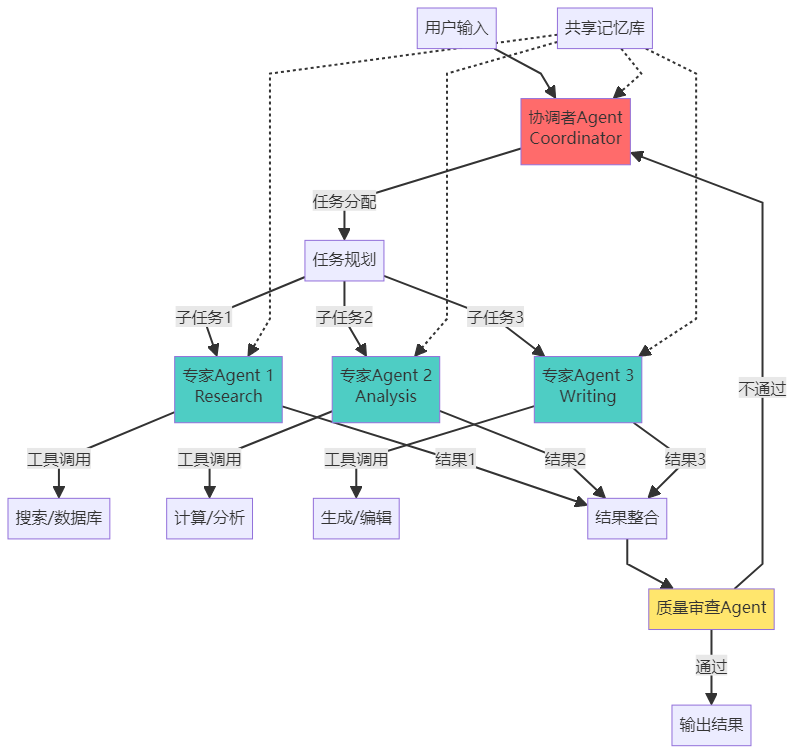

例如软件开发任务可以拆成产品分析、系统设计、前端开发、后端开发和测试。角色可以使用同一个底层模型，不一定需要五种不同的模型。

适合拆分的任务通常有两个特点：**子任务能定义清楚，交付结果能检查。** 如果所有角色都在重复阅读同一份材料、给出相似意见，增加角色可能只会增加通信和费用。

## 层级结构：由管理者分配任务

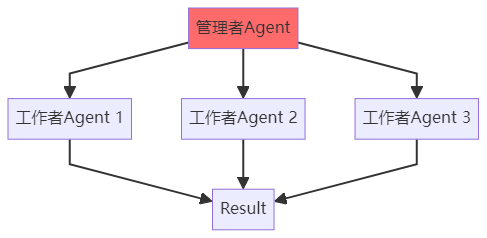

管理者负责理解目标、分配任务、检查进度和整合结果。工作者只处理自己负责的一部分。

以市场报告为例，研究员收集资料，分析员提取趋势，写作者组织报告。管理者需要传递的不只是“写一份报告”，还包括范围、来源要求和交付格式。

~~~json
{
  "task_id": "market_002",
  "from": "manager",
  "to": "analyst",
  "type": "task",
  "payload": {
    "goal": "比较三个产品的定位和价格",
    "source_task_ids": ["research_001"],
    "expected_output": {
      "comparison": "结构化对比表",
      "sources": "对应来源",
      "uncertainties": "仍然缺失的信息"
    }
  }
}
~~~

管理者读取结果后，要检查字段是否齐全、结论是否有证据。不能因为某个工作者说“已完成”，就直接把任务标成成功。

模型生成的分工计划如果是 JSON 文本，应先解析、校验，再遍历执行。`llm.invoke(...)` 返回的消息对象不会自动变成可执行任务列表。

## 平等协作：研究、质疑和修改

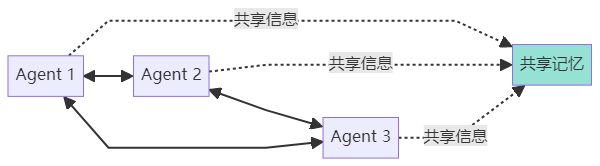

平等协作没有固定的上下级。不同角色提供不同视角，例如研究员提出方案，评审者指出证据不足的地方，写作者根据这些反馈修订。

这里的“讨论”仍需要规则：谁可以发言，一轮讨论解决什么问题，最多讨论几轮，最终由谁交付。

~~~text
第一轮：研究员提交方案和证据
第二轮：评审者列出具体问题及其依据
第三轮：研究员补充资料或修改方案
第四轮：写作者整理最终结果与未解决的问题
~~~

多个 Agent 一致同意，不等于结论一定正确。它们可能使用相同模型、相同资料，因而犯同一种错误。验证事实仍应回到来源、计算结果或业务数据。

## 流水线：每个阶段加工同一份任务材料

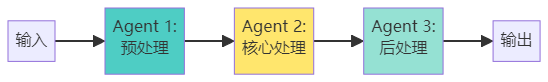

流水线适合步骤相对固定的任务。例如内容生产可以按“研究 → 大纲 → 草稿 → 编辑 → 发布前检查”执行。

每一步最好读取并返回结构一致的状态，而不是前一步返回字典，后一步突然按字符串处理。

~~~python
def run_pipeline(topic, stages):
    state = {"topic": topic}

    for name, stage in stages:
        updates = stage(dict(state))
        if not isinstance(updates, dict):
            raise TypeError(f"{name} 必须返回字典")
        state.update(updates)

    return state

# 用固定数据展示传递过程，真实阶段可以调用模型或工具。
stages = [
    ("research", lambda state: {"sources": ["资料 A", "资料 B"]}),
    ("outline", lambda state: {
        "outline": f"围绕 {state['topic']}，根据 {len(state['sources'])} 份资料列大纲"
    }),
]
print(run_pipeline("Agent 的应用", stages)["outline"])
~~~

`state.update(updates)` 把本阶段产物放进共享任务状态。后续阶段既能读到最初的主题，也能读到研究阶段找到的资料。

实际系统还需要为每一阶段声明输入字段和输出字段，并记录阶段状态。上面的字典只展示数据如何传递。

## 软件开发团队：并行之前先确定接口

软件开发可以结合前面三种模式：产品经理和架构师先确定需求、数据结构和 API；前后端在约定清楚后并行开发；随后进行集成、测试和审查。

~~~text
需求 → 产品说明 → 架构与接口约定
                         ├─ 前端实现 ─┐
                         └─ 后端实现 ─┤
                                      ↓
                                集成与测试
                                      ↓
                           通过，或返回有限次数修复
~~~

前端和后端可以并行，是因为已经有共同接口。如果一边假设字段叫 `user_name`，另一边返回 `username`，两个任务各自“完成”也不代表产品能运行。

并行执行骨架如下，`frontend` 与 `backend` 是传入的开发函数：

~~~python
from concurrent.futures import ThreadPoolExecutor

def develop_parts(spec, frontend, backend):
    with ThreadPoolExecutor(max_workers=2) as pool:
        front_task = pool.submit(frontend, spec["frontend"])
        back_task = pool.submit(backend, spec["backend"])
        return {
            "frontend": front_task.result(),
            "backend": back_task.result(),
        }
~~~

两个函数仍要在自己的调用中设置超时。线程池负责同时调度，不会自动保证网络请求及时结束。

测试失败后应把具体失败反馈交给相应角色，保留已经正确的成果。无上限地递归调用“重新开发整个项目”，会丢失进度，也可能永远无法结束。

## 协作中的通信、死锁和结果冲突

| 问题 | 典型表现 | 处理办法 |
| --- | --- | --- |
| 通信开销 | 每个角色反复阅读全部聊天记录 | 用任务 ID、结构化结果和必要摘要交接 |
| 循环依赖 | A 等 B，B 又等 A | 调度前检查依赖图，设置超时和明确失败状态 |
| 结果冲突 | 两个角色对同一事实给出不同结论 | 对照来源和验证结果，必要时交给负责人裁决 |
| 工作重叠 | 两个角色同时修改同一份产物 | 明确责任范围，合并前检查差异 |
| 责任不清 | 每个角色都认为应由别人收尾 | 指定最终交付者和完成标准 |

结构化消息可以避免让模型重新理解“任务由谁完成、结果放在哪里”这类确定信息。自然语言适合解释复杂结论，状态字段适合调度程序读取。

投票适合汇总偏好，不能替代事实验证。用模型自己声明的“信心 0.95”作为投票权重，也不能证明意见更可靠。

## 开发框架：先看它替你管理了什么

框架主要减少模型接入、工具包装、状态管理和流程编排的重复劳动。选择框架之前，先确认任务更依赖工具调用、角色协作，还是固定业务流程。

下面保留原文的五类框架，并把对比重点放在学习和使用方式上。项目接口与能力会随版本变化。

| 框架 | 原文列出的开发方 | 主要组织方式 | 适合重点学习的内容 | 上手时的关注点 |
| --- | --- | --- | --- | --- |
| LangChain | LangChain Inc | 模型、工具、检索、组合调用 | 通用模型应用与 RAG/Agent 集成 | 组件如何传递数据，所用版本的状态管理方式 |
| AutoGen | Microsoft | 多 Agent 消息与团队协作 | 角色之间如何交接和终止 | 通信协议、调度和运行环境 |
| CrewAI | CrewAI | Agent、Task、Crew | 用角色和任务组织团队流程 | 任务依赖与 expected output |
| Dify | Dify.ai | 可视化节点与工作流 | 快速搭建应用、知识库与业务分支 | 节点输入输出、部署和调用日志 |
| LazyLLM | 商汤 | 模型应用组件与流程编排 | 模型接入、部署与应用组织 | 模型兼容性和实际部署需求 |

“生态丰富”不等于每个项目都需要庞大的框架。只有两三个固定步骤时，普通函数和显式状态也可能足够；复杂任务需要中断恢复、追踪和协作时，运行时能力才更重要。

## LangChain：模型、工具、提示与执行器

阅读 LangChain 示例时，可以先把代码拆回前面学过的职责：

| 概念 | 在 Agent 中的作用 |
| --- | --- |
| Model | 接收消息并产生回答或工具请求 |
| Tool | 包装函数、参数结构和用途说明 |
| Prompt | 组织任务要求与上下文 |
| Parser / Schema | 把模型输出解析为可检查的数据 |
| Agent / Runtime | 根据状态决定下一步，并执行循环 |
| Memory / State | 保存消息、任务和工具结果 |
| Retriever | 从外部知识中取回相关内容 |

原文使用了 `create_react_agent`、`AgentExecutor` 和若干旧式 Memory 类。理解时应抓住组装关系，实际写项目时按锁定版本的文档选择对应接口。

~~~text
用户问题
  → 组装提示、状态和工具定义
  → 模型产生工具请求
  → 执行器调用工具
  → 工具结果写回状态
  → 模型继续或给出最终回复
~~~

在 RAG 场景中，还会出现文档加载、切分、Embedding、向量存储和检索。Agent 可以把检索器作为工具，在需要知识时调用。

形如 `prompt | model | parser` 的链式组合，表示前一个组件的输出交给后一个组件。它描述数据流，本身并不必然包含 Agent 的自主循环。

## AutoGen 与 CrewAI：消息协作和任务协作

AutoGen 示例把角色建成能够收发消息的 Agent。研究员、工程师、设计师可以通过团队或消息机制交接结果，运行时决定谁继续工作、什么时候结束。

需要分别考虑两件事：**能聊天**和**能完成任务**。一个群聊讨论十轮，不一定产生可使用的产物，因此仍需要结果结构和终止条件。

CrewAI 的原文示例更接近团队分工：

~~~text
Agent：
  researcher → 查找、核对资料
  writer     → 根据资料写文章

Task：
  research_task → 交付有来源的研究结果
  writing_task  → 依赖 research_task，交付完整文章

Crew：
  组织角色与任务，决定执行流程
~~~

`role` 说明职责，`goal` 说明目标，`tools` 说明可用能力；任务中的 `expected_output` 则把“做什么”落实为“交付什么”。

无论选择哪一种组织方式，都应显式传递前一步结果。仅让两个角色分别运行一次，不会自动建立“文章必须依据研究结果”的联系。

## Dify 与框架选型：从业务流程倒推工具

Dify 的节点画布适合把处理路径展示出来：

~~~text
用户输入
  → 意图识别
  → 条件分支
      ├─ 知识问题 → 知识库检索 → 根据资料回答
      ├─ 订单问题 → 检查订单号 → 调用业务 API
      └─ 信息不足 → 追问
  → 输出
~~~

每个节点仍然有输入、输出、异常和上下文。可视化减少了编排代码，并没有消除业务设计。

选型可以先做一个小型验证任务：需要几个工具、是否需要跨轮记忆、是否需要人工介入、失败能否恢复、日志能否追踪、部署是否方便。再用同一任务比较候选框架。

原文把 LazyLLM 列为国内应用与部署的一种选择。实际选择仍要核对模型适配、服务方式、许可证和维护情况，不能只根据“中文场景”作决定。

## 实战一：智能客服，先分清知识问题和业务操作

电商客服通常需要回答 FAQ、查询订单、处理退换货和转人工。这几类请求的数据来源与执行方式不同。

| 用户请求 | 需要什么 | 成功的标准 |
| --- | --- | --- |
| “支持哪些支付方式？” | 有效的 FAQ 或知识库 | 回答与当前规则一致 |
| “订单到哪了？” | 订单号、用户身份、物流数据 | 查到当前用户的正确订单 |
| “我想申请退款” | 订单状态、退款规则、申请流程 | 判断资格并完成对应业务步骤 |
| “我要找人工客服” | 转接服务和必要上下文 | 确认转接是否真正建立 |

“退货规则”是知识查询，“提交退货申请”是业务操作。不能只凭两个问题都包含“退货”就走相同工具。

FAQ 检索可以使用 RAG：检索规则片段，带上来源与有效时间，再组织回复。订单查询应调用业务工具，而不是让模型从知识库里猜测个人订单状态。

客服的短期状态至少应记录当前意图、订单号、缺少的字段和上一次工具结果。后面的意图识别部分会把这条流程写成可运行的多轮示例。

## 客服中的情绪与转人工

用户说“我等了三天，非常不满意”，说明回复应先承认问题，再解决具体事项。情绪识别可以辅助调整语气，但关键词匹配只是一个粗糙信号。

“不差”不一定是负面，“没生气”也不等于“生气”。如果仅检查单个字词，很容易误判。

转人工最好由明确状态触发，例如用户直接要求、业务规则需要人工处理、工具连续失败，或系统无法判断关键事项。不能只搜索模型回复里有没有“复杂问题”几个字。

转交的信息可以整理成：

~~~json
{
  "session_id": "session_001",
  "intent": "refund",
  "order_id": "ORD123456",
  "summary": "用户申请退款，订单状态查询暂时失败。",
  "attempted_steps": ["查询订单", "重试查询"],
  "unresolved": "订单是否满足退款条件"
}
~~~

这里的任务摘要能减少用户重复说明。真正连接人工服务后，再根据服务返回的排队或转接状态回复；不能只把请求放进本地列表，就声称人工客服已经接入。

## 实战二：代码生成，测试结果要回到修复循环

代码生成 Agent 的任务不止是输出代码块。一个完整流程包括理解需求、生成实现、执行测试、根据失败修复，以及整理说明。

以“计算数字列表的平方和”为例，测试至少覆盖普通输入、空列表、负数和非数字。程序没有语法错误，不代表它满足这些要求。

下面把模型和测试环境作为函数传入，集中展示有限次数的修复循环：

~~~python
def generate_with_repairs(requirement, generate, test, repair, max_repairs=2):
    if max_repairs < 0:
        raise ValueError("max_repairs 不能为负数")

    code = generate(requirement)

    for attempt in range(max_repairs + 1):
        report = test(code)
        if report["passed"]:
            return {"ok": True, "code": code, "report": report}

        if attempt == max_repairs:
            return {"ok": False, "code": code, "report": report}

        code = repair(requirement, code, report)
~~~

`max_repairs=2` 表示初次测试失败后，最多修复两次，总共最多测试三版代码。失败报告必须进入 `repair`，否则修复函数不知道上一版哪里出错。

`generate` 和 `repair` 可以由模型实现，`test` 应在适当隔离的环境执行验收测试。这段控制代码本身不会运行任意模型生成的程序。

测试环境至少应提供退出状态、标准输出、错误信息和超时结果。`subprocess.run(timeout=5)` 只控制等待时间，不能替代文件、网络和资源的隔离。

## 代码生成的完成标准

原文在代码通过测试后，再让模型添加注释和文档。这个顺序有一个容易忽略的问题：模型添加说明时，也可能改变代码行为。

更稳妥的顺序是：

1. 根据需求明确输入、输出与边界条件。
2. 生成实现和必要说明。
3. 执行验收测试。
4. 有修改就重新检查。
5. 交付最终代码、使用方式和已验证范围。

测试本身也需要检查。若实现和测试都由同一个模型按同一种错误理解生成，二者可能一致通过，却一起偏离需求。

最终应保存交付的那一版代码和相应测试报告。不能把上一版的“测试通过”标记沿用到后来又修改过的代码。

## 实战三：数据分析，让计算结果支撑文字结论

数据分析 Agent 可以完成“读取 Excel → 检查字段 → 清洗数据 → 统计分析 → 生成图表 → 撰写报告”。

例如“找出销售额最高的三个地区”，先要确认表里哪个字段代表销售额，金额单位是什么，退款和缺失数据怎样处理。

模型可以根据字段说明提出结构化计划：

~~~json
{
  "steps": [
    {"action": "validate", "columns": ["region", "sales"]},
    {"action": "group_sum", "group_by": "region", "value": "sales"},
    {"action": "sort", "by": "sales", "ascending": false},
    {"action": "top_k", "k": 3},
    {"action": "bar_chart", "x": "region", "y": "sales"}
  ]
}
~~~

执行器应只接受支持的动作和真实存在的字段。模型写出一个列名，不代表这个列真的在表里。

清洗规则也会改变结论。缺失金额究竟应该剔除、补零还是回查，取决于数据含义，不能默认把所有异常值改成 0。

## 用 Pandas 实现一个具体分析步骤

下面的代码不依赖模型，用演示数据执行分组求和，并保留被剔除的记录数量。需要安装 `pandas`；读取 Excel 时通常还需要相应引擎，例如 `openpyxl`。

~~~python
import pandas as pd

def analyze_sales(df):
    required = {"region", "sales"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"缺少字段：{sorted(missing)}")

    work = df[["region", "sales"]].copy()
    work["region"] = work["region"].astype("string").str.strip()
    work["sales"] = pd.to_numeric(work["sales"], errors="coerce")

    valid = (
        work["region"].notna()
        & work["region"].ne("")
        & work["sales"].notna()
    )
    clean = work.loc[valid]
    totals = clean.groupby("region")["sales"].sum().sort_values(ascending=False)

    return {
        "top3": totals.head(3),
        "excluded_rows": int((~valid).sum()),
        "valid_rows": len(clean),
    }

demo_sales = pd.DataFrame({
    "region": ["华东", "华南", "华东", "华北", "华南"],
    "sales": [120, 80, 30, 90, None],
})
sales_report = analyze_sales(demo_sales)
print(sales_report["top3"])
print("剔除行数：", sales_report["excluded_rows"])
~~~

输出中，华东合计为 150，华北为 90，华南为 80；有一条缺失金额被剔除。报告应同时解释这种处理方式。

将 `demo_sales` 换成 `pd.read_excel("sales_data.xlsx")`，就接上了文件输入。模型负责解释分析结果时，应读取这些真实统计值，而不是重新心算一遍。

若需要图表，可以对结果绘制柱状图，并保存明确的文件名：

~~~python
import matplotlib.pyplot as plt

ax = sales_report["top3"].plot.bar()
ax.set_xlabel("地区")
ax.set_ylabel("销售额")
ax.set_title("各地区销售额前 3 名")
plt.tight_layout()
plt.savefig("sales_top3.png", dpi=160, bbox_inches="tight")
plt.close()
~~~

中文字体需要按本地环境配置；金额单位应使用数据实际的单位。生成报告时同时记录数据范围、统计口径、排除记录和图表位置。

## Agent 的发展方向

原文最后讨论了三个方向，可以联系前面的架构理解。

**更强的推理能力**有助于拆解复杂目标、发现计划中的问题，以及在执行失败后调整方案。但实时状态和精确业务数据仍需要工具提供。

**多模态能力**让输入不再限于文本。系统可以理解设计草图、图表、语音或视频，再把识别结果接入执行流程。例如从界面草图提取布局要求，再生成页面并检查渲染结果。

**更持久的个性化记忆**可以减少重复询问，让跨会话任务更连贯。它同时要求信息可更新、可纠正、可过期，并且准确区分“用户长期偏好”和“本次临时要求”。

这些能力最终都要回到任务质量：能否理解目标、使用正确的数据、可靠执行，并交付可以检查的结果。

## 意图识别：先弄清用户要办什么事

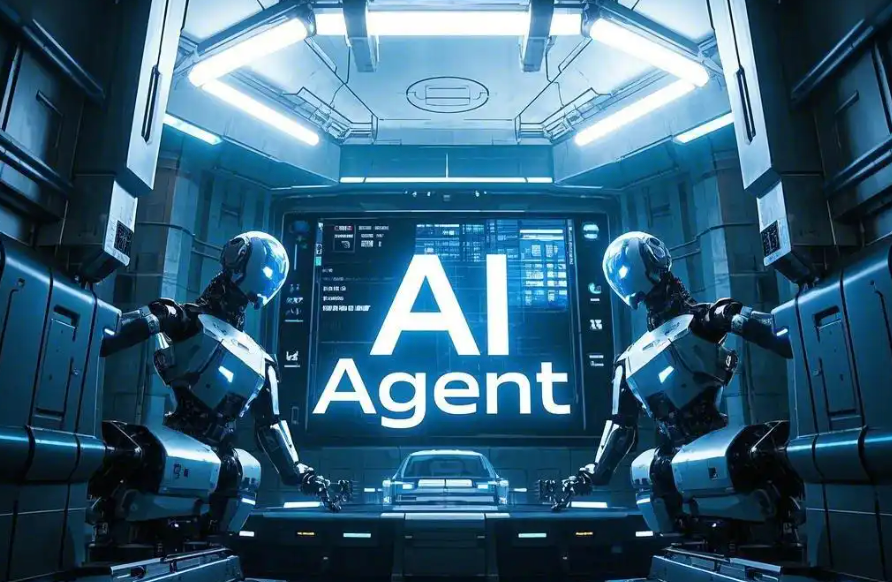

在咖啡店里，顾客说“来一杯大杯拿铁，不加糖，带走”，店员会把一句话理解成几项信息：

- 要做的事：点单。
- 商品：拿铁。
- 规格：大杯。
- 要求：不加糖、打包。

Agent 的意图识别做的是类似的转换：把自然语言变成可以交给程序处理的任务类别和参数。

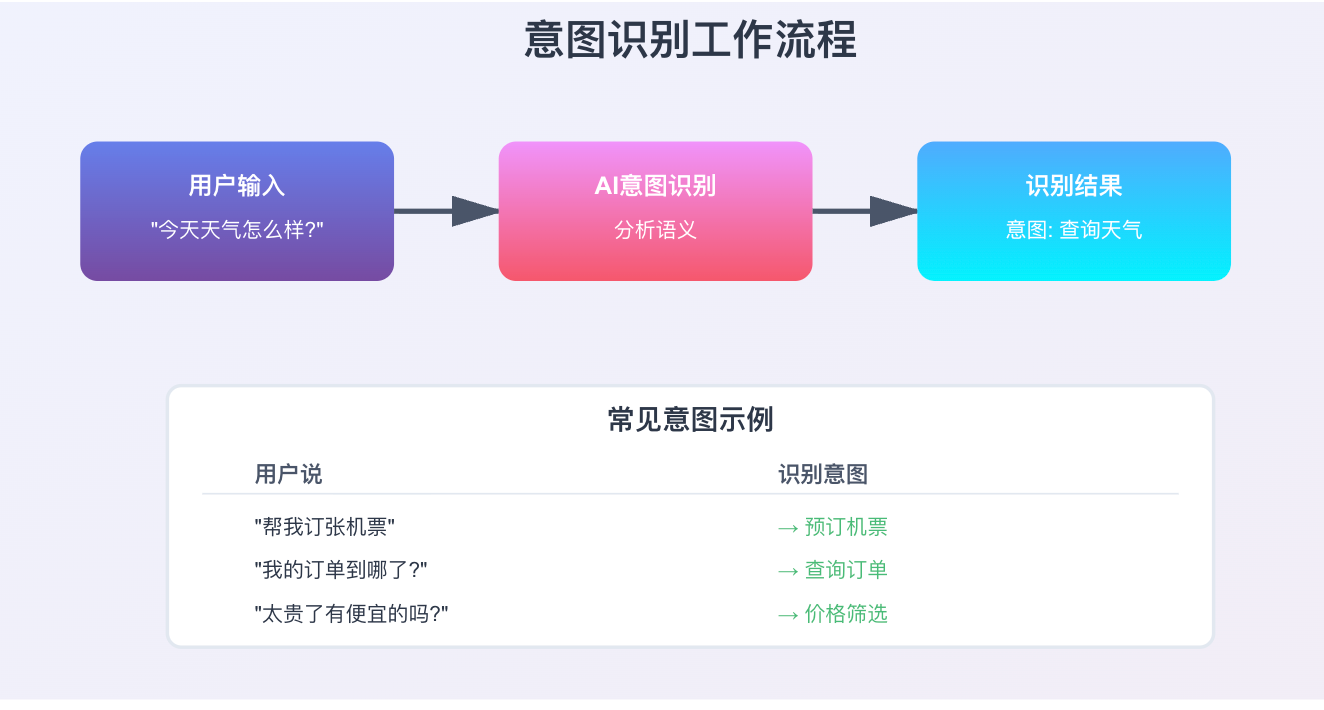

意图识别通常处于感知层与决策层之间。识别错了，后面的工具即使执行成功，也可能处理了错误的事情。

## 意图、槽位和动作分别是什么

**意图（Intent）**是用户想做什么，例如查询天气、查询订单、申请退款。**槽位（Slot）**是完成这件事所需要的参数，例如城市、日期和订单号。**动作（Action）**是系统下一步实际执行什么。

原文用下面几组例子说明它们的联系：

| 用户说的话 | AI 识别的意图 | 应该做什么 |
| --- | --- | --- |
| “今天天气怎么样？” | 查询天气 | 补齐城市后调用天气 API |
| “帮我订张去北京的机票” | 预订机票 | 进入订票流程，收集缺失信息 |
| “我的订单到哪了？” | 查询订单 | 确定订单号后查询物流 |
| “太贵了，有便宜点的吗？” | 价格筛选 | 结合当前商品或搜索条件推荐低价商品 |

同一句话也可能依赖上下文。“太贵了”单独出现时，无法知道是在说酒店、机票还是商品；需要查看前面正在讨论的对象。

因此，意图识别不一定是“输入一句话，立即调用一个工具”。它也可能得出“已经理解任务，但需要再问一个参数”。

## 三层处理：文本理解、意图分类、槽位填充

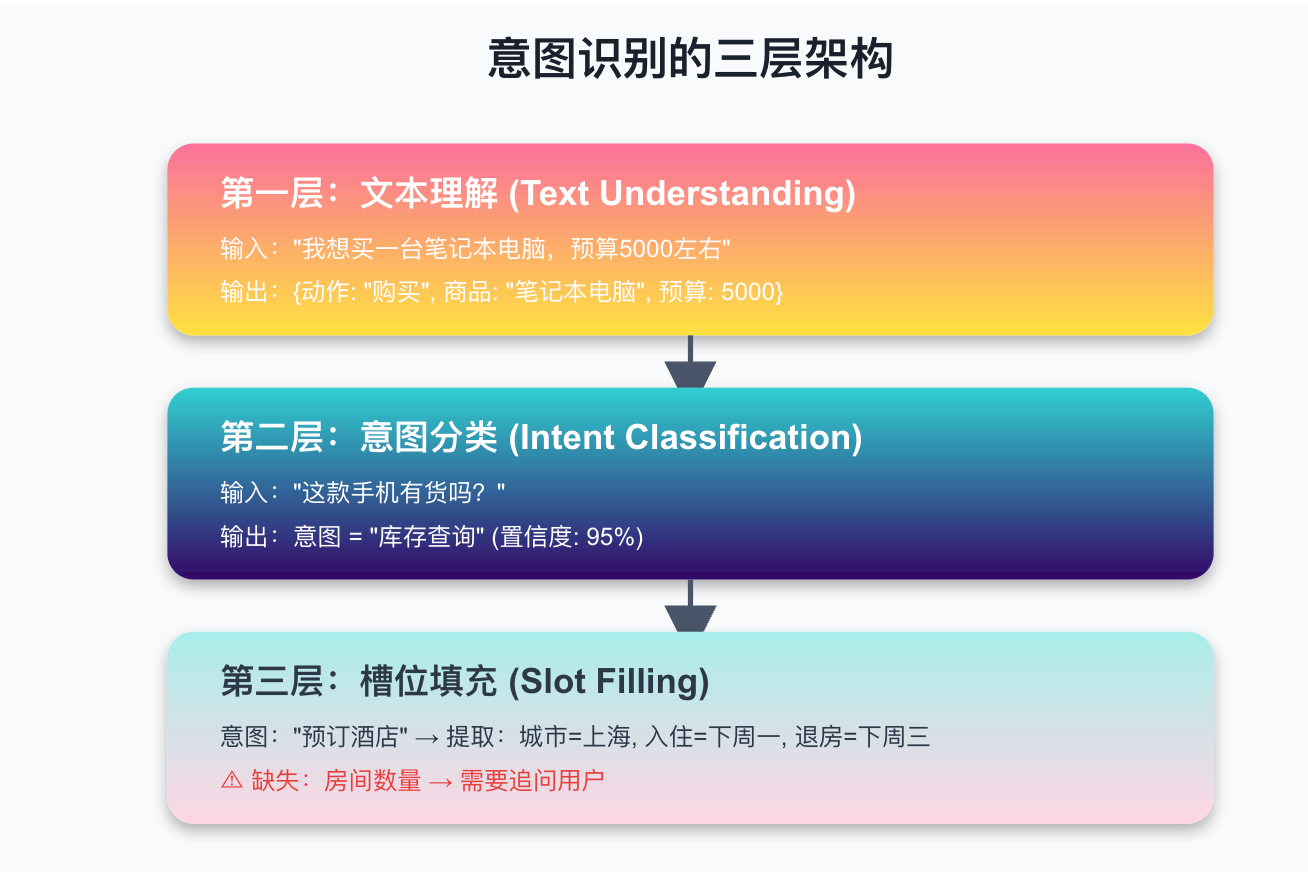

以“帮我订明天从上海到北京的两张机票”为例：

| 层次 | 处理结果 |
| --- | --- |
| 文本理解 | 用户请求购票，包含日期、路线和数量 |
| 意图分类 | booking |
| 槽位填充 | departure=上海，destination=北京，date=明天对应日期，quantity=2 |

这些步骤在代码里可以是独立模块，也可以由同一个模型返回结构化结果。无论怎样实现，最后都需要检查字段是否完整、取值是否有效。

例如识别出“订票”，还不能直接完成预订。航班、乘客信息、票价和付款等内容属于后续业务流程。

## 三种意图识别方法怎么选

| 方法 | 原理 | 优点 | 局限 |
| --- | --- | --- | --- |
| 规则匹配 | 关键词、正则和业务规则 | 快、可解释、适合明确指令 | 同义表达、否定、多意图难维护 |
| 传统机器学习 | 文本特征加分类器 | 推理成本低，可以建立稳定基线 | 依赖数据与特征，复杂语义能力有限 |
| BERT 等预训练模型 | 编码上下文后进行分类 | 能学习更丰富的语义关系 | 需要微调、评估和部署资源 |

实际系统可以组合使用：明确的“转人工”走规则，常见咨询走分类器，复杂或模糊表达再交给大模型判断。

选择方法前应定义意图边界。把“退款规则咨询”“申请退款”“取消退款”全部标成同一类，会把完全不同的后续操作混在一起。

## 文本预处理：清理格式，保留含义

预处理可以统一全角字符、清理多余空白，但不应随意删掉会改变含义的词。

“我要退款”和“我不要退款”只差一个“不”。如果把“不”放进停用词表，两个句子就可能变成相同特征。

下面保留原文，只做温和的格式规范化：

~~~python
import re
import unicodedata

def normalize_text(text):
    normalized = unicodedata.normalize("NFKC", text)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return {"original": text, "normalized": normalized}

print(normalize_text("  我不要退款，订单号是 ＯＲＤ１２３４５６。  "))
~~~

`original` 用于追溯用户真实表达；`normalized` 用于规则匹配或特征处理。订单号、日期、金额里的字符需要保留。

是否分词、是否去停用词，应与模型的训练方式一致。BERT 通常使用模型配套的 tokenizer，不需要再先套一遍通用中文停用词清理。

## 规则识别：先做一个可解释的基线

下面的规则识别器用于后面的演示客服。它覆盖少量明确表达，遇到否定退款和多个任务时，返回需要澄清的状态。

~~~python
INTENT_PATTERNS = {
    "human": r"转人工|人工客服|人工服务|找客服|联系客服",
    "refund": r"退款|退货|退钱",
    "booking": r"订票|买票|机票|车票|高铁票|订.*张.*票",
    "weather": r"天气|气温|温度|下雨|晴天",
    "order": r"订单|物流|快递|包裹|到哪了|什么时候能到",
}

def recognize_rule(text):
    text = normalize_text(text)["normalized"]
    if re.search(r"(不想|不要|不需要|取消).{0,3}(退款|退货)", text):
        return {"intent": None, "reason": "refund_negation"}

    hits = [
        name for name, pattern in INTENT_PATTERNS.items()
        if re.search(pattern, text)
    ]

    # “订单 ORD123456 申请退款”中的订单号是退款对象。
    if set(hits) == {"refund", "order"} and not re.search(
        r"查询|查一下|然后|另外|同时", text
    ):
        hits.remove("order")

    if len(hits) == 1:
        return {"intent": hits[0], "reason": "matched_rule"}
    if len(hits) > 1:
        return {"intent": None, "reason": "multiple_intents"}
    if text.lower().strip("！!。？?") in {"你好", "您好", "嗨", "hello", "hi", "在吗"}:
        return {"intent": "greeting", "reason": "matched_rule"}
    return {"intent": None, "reason": "no_match"}
~~~

这里返回 `reason`，方便知道是没有命中、命中多个意图，还是出现需要特别处理的否定表达。

规则命中不等于有“90% 的真实正确率”，因此没有随意写一个固定的 `confidence=0.9`。如果需要衡量可靠性，应在标注样本上统计效果。

这组规则的覆盖范围有限，例如“这件商品能不能退”还需要增加表达方式或交给分类模型。演示规则不会因为写成函数就自动具备完整语言理解能力。

## 机器学习：从标注样本学习分类

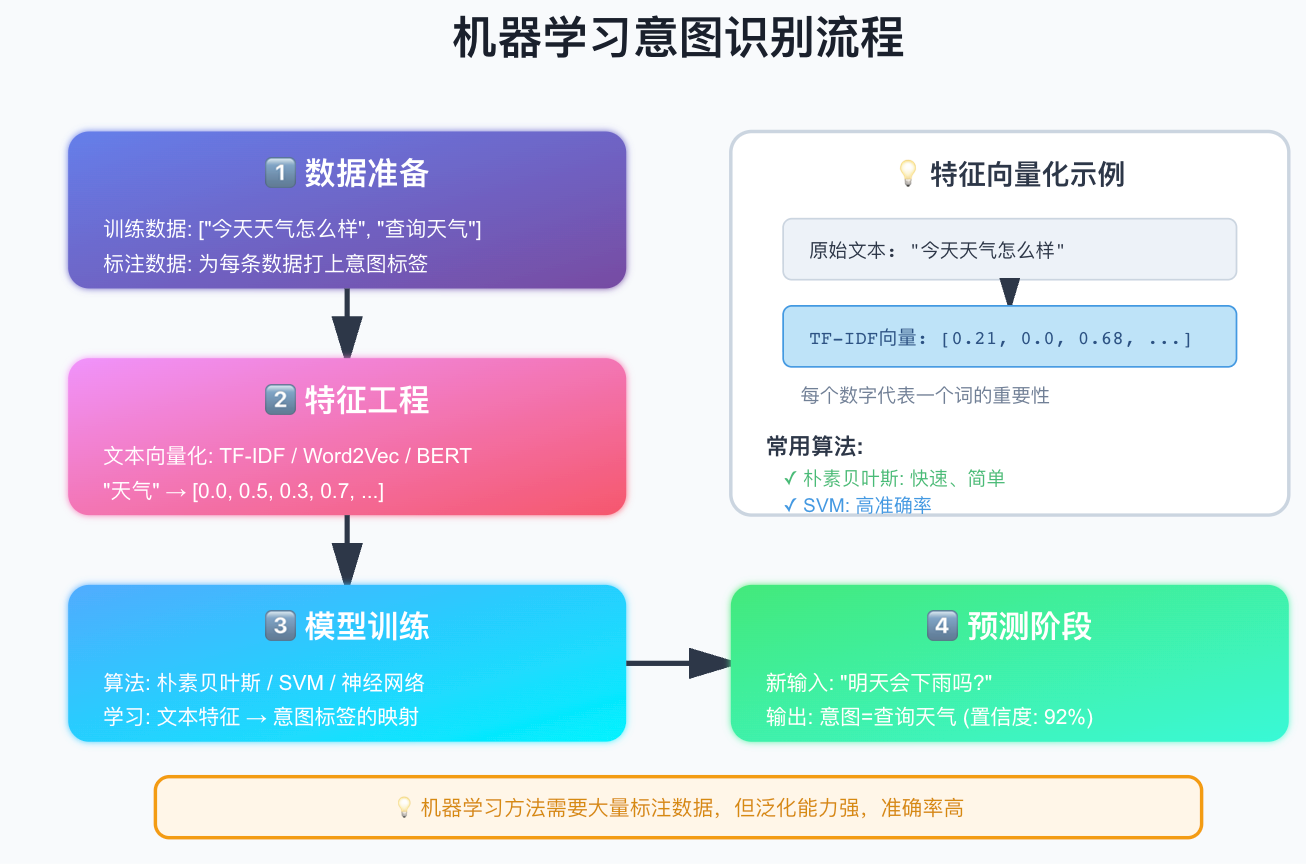

训练数据由“文本、标签”组成。TF-IDF 把文本转换为数值特征，分类器根据这些特征学习不同意图的区别。

中文可以先用 jieba 分词，再按词提取特征。这里使用**字符 n-gram**：把相邻的 1～3 个字符作为特征，避免依赖中文空格分词。

下面是一个小型演示，需要 `scikit-learn`。数据量只适合说明流程，不能据此判断真实业务准确率。

~~~python
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

examples = {
    "weather": ["今天天气怎么样", "北京现在多少度", "明天会下雨吗",
                "气温高不高", "周末是晴天吗", "查一下上海天气"],
    "booking": ["帮我订一张机票", "买票去上海", "预订高铁票",
                "我要购买火车票", "订两张去北京的车票", "帮忙买张机票"],
    "order": ["我的订单到哪了", "快递什么时候到", "查询物流",
              "包裹在哪", "查一下订单状态", "订单发货了吗"],
    "refund": ["我要退款", "申请退货", "请帮我退钱",
               "这笔订单要退款", "我想退货", "我要办理退款"],
    "human": ["转人工客服", "帮我找客服", "需要人工服务",
              "我要联系人工", "请转人工", "找人工客服处理"],
}
texts = [text for samples in examples.values() for text in samples]
labels = [label for label, samples in examples.items() for _ in samples]

train_x, test_x, train_y, test_y = train_test_split(
    texts, labels, test_size=1/3, stratify=labels, random_state=42
)

intent_model = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 3))),
    ("classifier", MultinomialNB()),
])
intent_model.fit(train_x, train_y)
~~~

`Pipeline` 把特征提取和分类器绑在一起，预测时会使用训练阶段建立的同一份词表。

`fit` 只对训练集执行。先用全部文本建立 TF-IDF，再划分测试集，会把测试集信息提前带入特征处理。

真实项目通常保留训练集、验证集和测试集：训练参数用训练集，选择阈值和超参数用验证集，最终报告用测试集。

## 分类结果与分数怎么读取

~~~python
import numpy as np

def predict_intents(model, texts):
    if not texts:
        return []
    probabilities = model.predict_proba(texts)
    classes = model.classes_
    indices = np.argmax(probabilities, axis=1)

    return [
        {
            "intent": str(classes[index]),
            "score": float(row[index]),
            "scores": {
                str(label): float(value)
                for label, value in zip(classes, row)
            },
        }
        for row, index in zip(probabilities, indices)
    ]

print(predict_intents(intent_model, ["今天会不会下雨", "我的快递到哪了"]))
~~~

这里一次传入多条文本，向量化和分类器也按批处理。`classes_` 决定概率数组各列对应的标签，不能凭自己想象的顺序解释。

朴素贝叶斯返回的概率估计不一定经过良好校准。最高分很高，也可能遇到业务范围之外的句子；只在五类中“选一个最像的”，不代表输入真的属于其中之一。

可以结合验证集、范围外样本和分数差距设计拒识规则，低把握时追问，而不是强行路由。

## BERT：先理解上下文，再映射到意图标签

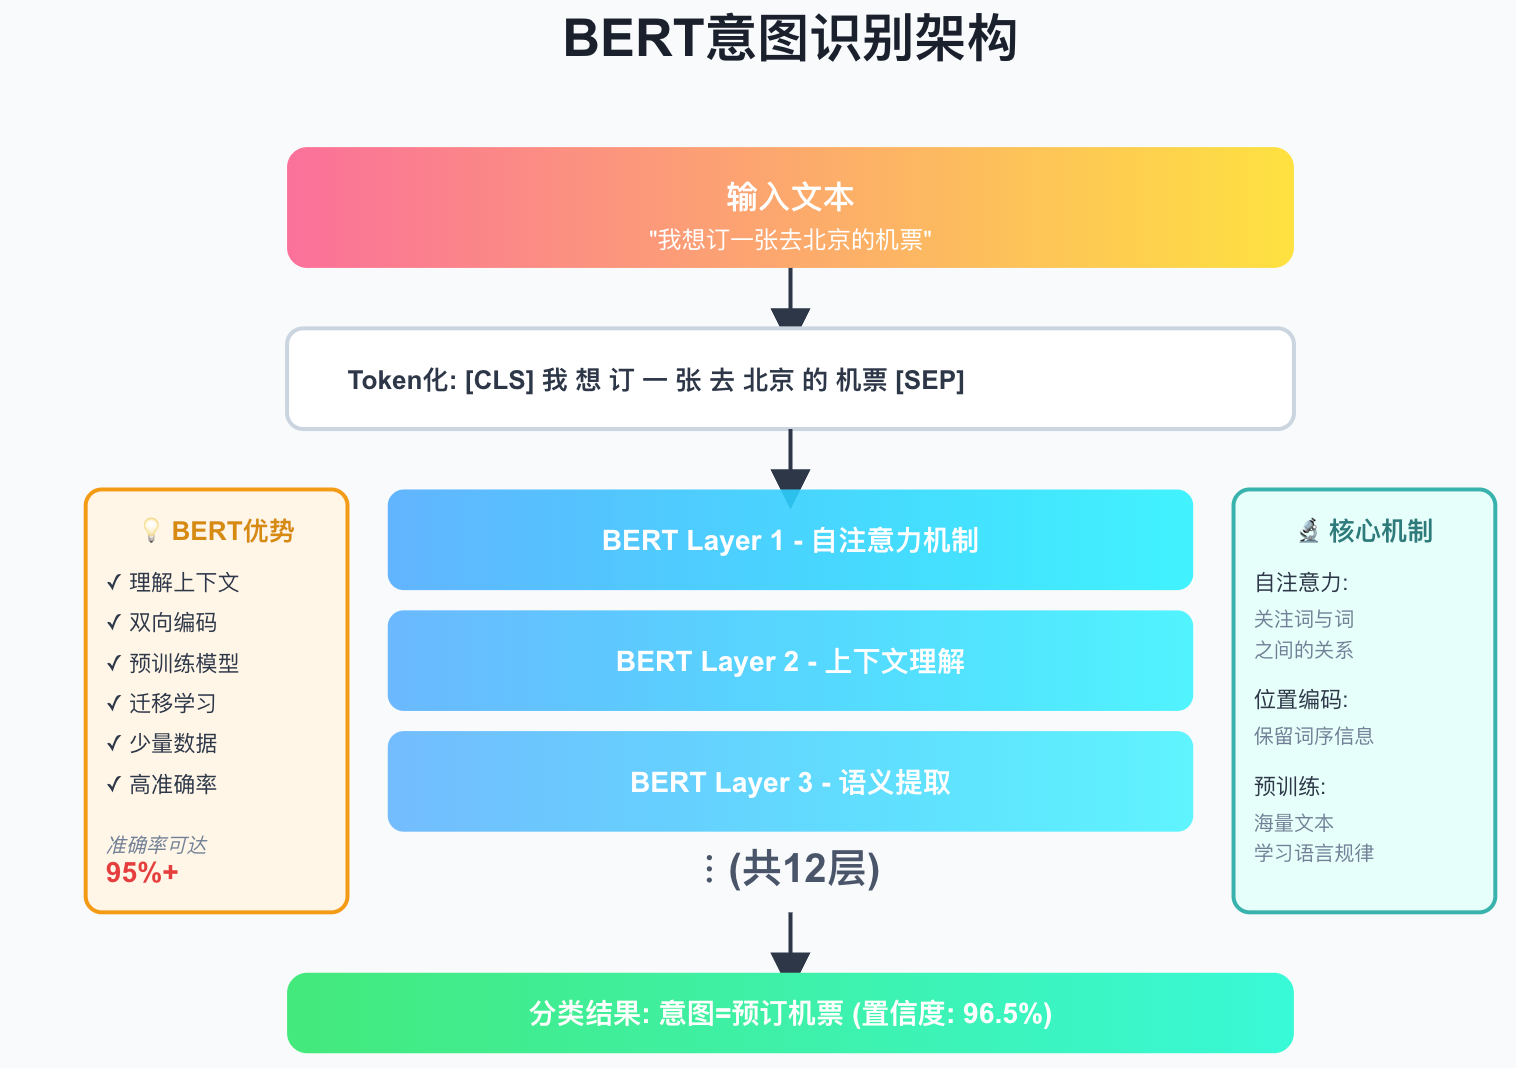

BERT 对输入序列进行上下文编码，分类头把文本表示映射成各意图的分数。相比纯关键词，它有能力学习“同样一个词，在不同上下文里是什么意思”。

原图中的准确率与置信度数字用于示意结构，并不是下面这段代码已经取得的评估结果。

但下载 `bert-base-chinese` 并添加分类头，不会自动得到可用的客服分类器。新的分类头需要使用标注数据训练，效果还要在独立数据上验证。

标签与数字的映射必须稳定，并与模型一起保存：

~~~python
intent_labels = sorted(set(train_y))
label2id = {label: index for index, label in enumerate(intent_labels)}
id2label = {index: label for label, index in label2id.items()}
~~~

不能每次运行时随意用无序集合重新编号。训练时“0 表示退款”，加载时若“0 表示天气”，模型预测会被错误解释。

## BERT 微调：看懂一个训练批次

下面承接前面的 `train_x`、`train_y`，展示最小训练过程。需要 `torch` 和 `transformers`，首次加载模型需要下载权重；小样本示例用于理解代码，不代表训练完成后就达到业务要求。

~~~python
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-chinese",
    num_labels=len(intent_labels),
    label2id=label2id,
    id2label=id2label,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

def collate_intents(batch):
    batch_texts, batch_labels = zip(*batch)
    encoded = tokenizer(
        list(batch_texts), padding=True, truncation=True,
        max_length=128, return_tensors="pt",
    )
    encoded["labels"] = torch.tensor([label2id[x] for x in batch_labels])
    return encoded

loader = DataLoader(
    list(zip(train_x, train_y)),
    batch_size=8, shuffle=True, collate_fn=collate_intents,
)
optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

bert_model.train()
for epoch in range(3):
    for batch in loader:
        batch = {key: value.to(device) for key, value in batch.items()}
        optimizer.zero_grad()
        output = bert_model(**batch)
        output.loss.backward()
        optimizer.step()
~~~

`padding=True` 把同一批样本补到相同长度；`attention_mask` 标识哪些位置属于真实文本。`truncation=True` 会截断过长输入，因此长度上限也要结合业务评估。

`train()` 切换到训练模式，`backward()` 计算梯度，`step()` 更新参数。实际训练还需要验证集评估、随机种子、检查点和合适的停止策略。

## BERT 推理与模型保存

训练和推理使用不同的运行方式。推理时不更新参数，通常关闭梯度计算，并把模型切换到 `eval` 模式。

~~~python
def predict_bert(texts):
    if not texts:
        return []

    bert_model.eval()
    inputs = tokenizer(
        texts, padding=True, truncation=True,
        max_length=128, return_tensors="pt",
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.inference_mode():
        probabilities = bert_model(**inputs).logits.softmax(dim=-1)

    scores, indices = probabilities.max(dim=-1)
    return [
        {
            "intent": bert_model.config.id2label[index],
            "score": score,
        }
        for index, score in zip(indices.cpu().tolist(), scores.cpu().tolist())
    ]

# 训练并评估后，再保存模型与配套 tokenizer。
# bert_model.save_pretrained("intent_bert")
# tokenizer.save_pretrained("intent_bert")
~~~

`softmax` 把 logits 转为和为 1 的分数分布，但并不自动保证分数与真实正确率一致。

保存时要同时保留 tokenizer、模型、标签映射和训练配置。上线加载的是经过训练的目录，而不是重新加载基础模型再随机创建一个分类头。

## 把模块接成意图识别引擎

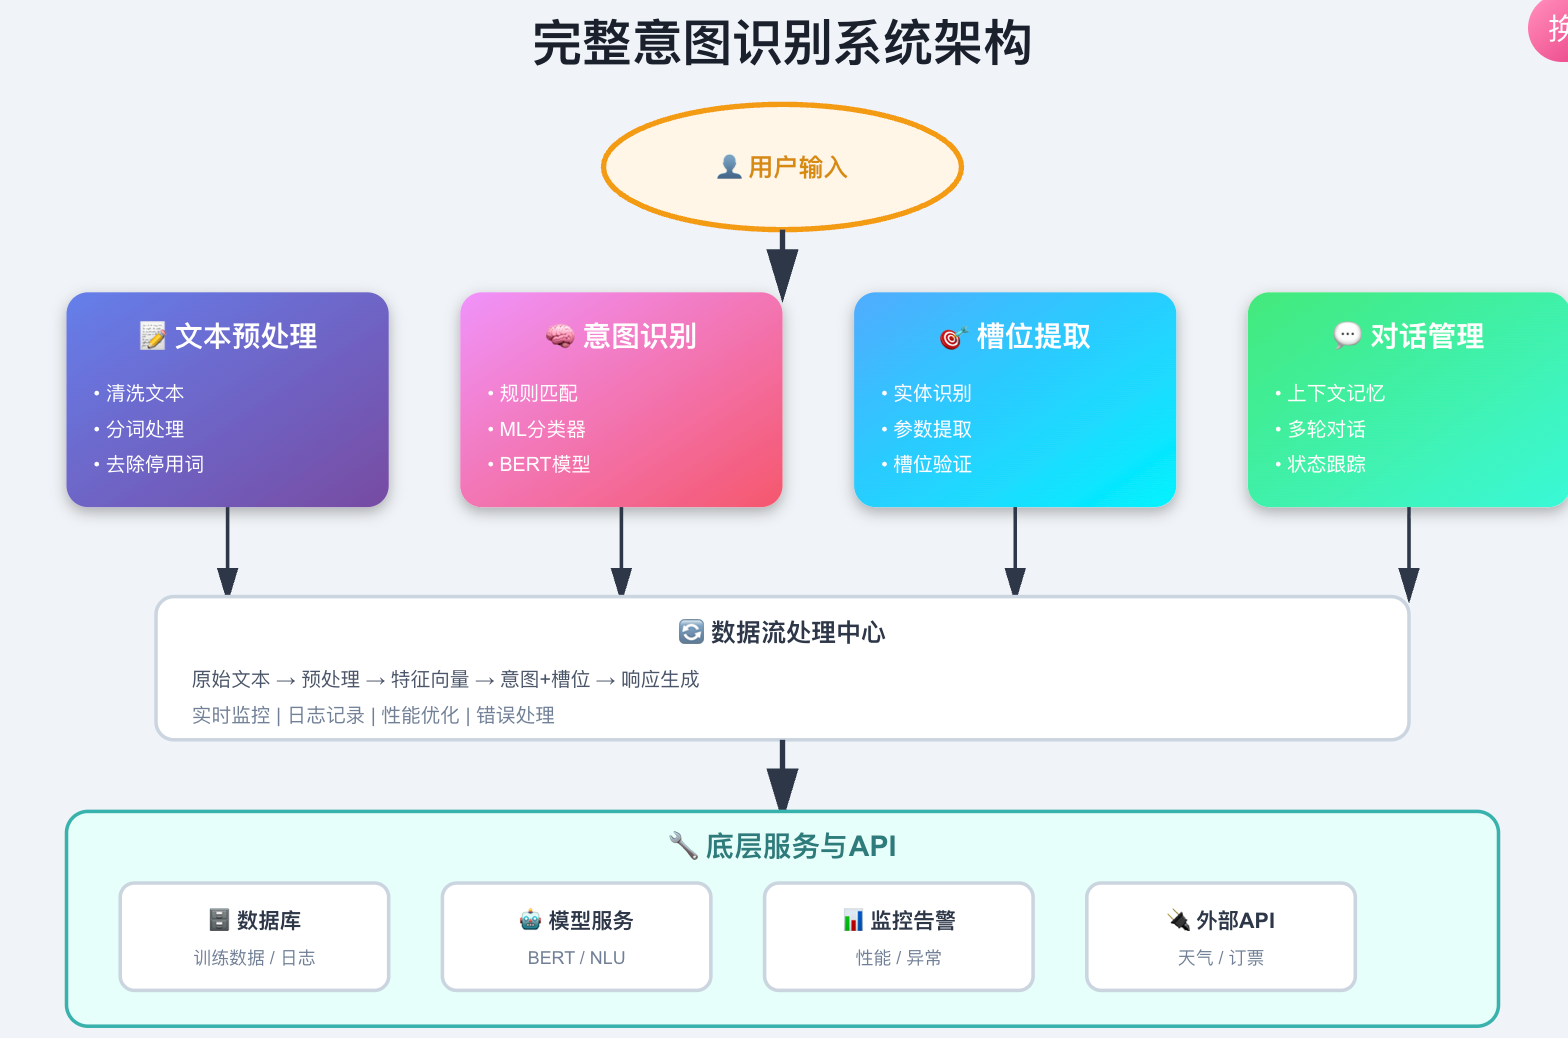

现在已经有预处理、分类器和标签。还缺两部分：从文本中提取参数，以及判断能不能进入业务执行。

引擎可以统一返回三种状态：

| 状态 | 表示什么 | 下一步 |
| --- | --- | --- |
| uncertain | 任务本身还不明确 | 澄清用户想办什么 |
| incomplete | 已知任务，但缺少必要参数 | 询问缺少的字段 |
| complete | 意图与必要参数齐全 | 交给业务工具继续处理 |

这里的 `complete` 只表示“请求信息完整”，不表示“机票已经订好”或“退款已经成功”。

接下来用规则识别器做一个无需模型下载的完整示例。以后可以把分类模块替换成前面的机器学习模型或 BERT，参数和对话状态的处理仍然需要保留。

## 槽位提取：先确定日期与业务字段

日期需要结合用户所在时区和当前时间。“明天”应转换成确定日期；“下周住两晚”没有说明具体哪一天，不能直接猜成周一。

下面演示相对日期和 ISO 日期。用参数传入 `today`，便于在固定日期复现结果：

~~~python
from datetime import date, timedelta

def extract_date(text, today):
    relative = {"今天": 0, "明天": 1, "后天": 2}
    candidates = set()
    for word, offset in relative.items():
        if word in text:
            candidates.add((today + timedelta(days=offset)).isoformat())

    for value in re.findall(r"\d{4}-\d{2}-\d{2}", text):
        candidates.add(date.fromisoformat(value).isoformat())
    if len(candidates) > 1:
        raise ValueError("存在多个日期，需要确认各自含义")
    return next(iter(candidates), None)
~~~

`date.fromisoformat` 会拒绝不存在的日期，例如 2026-02-30。无法解析的“下周”“周末”暂时不填入槽位，让系统继续询问。

对于同时包含多个日期或修改表达的句子，还需要确定日期角色。例如“今天订明天的票”，出发日期应是明天。这个简化函数遇到多个不同日期会要求澄清，扩展时可以增加针对预订时间、出发时间的语义解析。

## 槽位提取：城市、数量和订单号

下面只支持几个演示城市和有限的数量表达。规则是为了看清数据如何进入状态，真实系统需要更完整的地名和日期识别。

~~~python
CITY_PATTERN = r"北京|上海|广州|深圳|杭州|成都|武汉|西安"

def extract_slots(text, intent, today, expected_slot=None):
    text = normalize_text(text)["normalized"]
    slots = {}

    if intent in {"weather", "booking"}:
        found_date = extract_date(text, today)
        if found_date:
            slots["date"] = found_date

    if intent == "weather":
        cities = re.findall(CITY_PATTERN, text)
        if len(set(cities)) == 1:
            slots["city"] = cities[0]

    if intent == "booking":
        start = re.search(r"从(" + CITY_PATTERN + r")", text)
        end = re.search(r"(?:到|去)(" + CITY_PATTERN + r")", text)
        if start:
            slots["departure"] = start.group(1)
        if end:
            slots["destination"] = end.group(1)

        # 系统问“从哪里出发”时，单独的“上海”就是出发地。
        if expected_slot in {"departure", "destination"}:
            city = re.fullmatch(CITY_PATTERN, text)
            if city:
                slots[expected_slot] = city.group()

        quantity = re.search(r"([1-9]\d*|一|两|二|三|四|五|六|七|八|九|十)张", text)
        if quantity:
            value = quantity.group(1)
            chinese = dict(zip("一两二三四五六七八九十", [1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10]))
            slots["quantity"] = int(value) if value.isdigit() else chinese[value]

    if intent in {"order", "refund"}:
        order = re.search(r"(?<![A-Z0-9])ORD\d{6,}(?![A-Z0-9])", text.upper())
        if order:
            slots["order_id"] = order.group()

    return slots
~~~

`expected_slot` 保存“系统上一轮问的是什么”。“北京”既可能是出发地，也可能是目的地，只有结合这个状态才能正确填入。

订单号采用本示例明确约定的 `ORD` 加至少六位数字，能够匹配 `ORD123456`。真实项目应按业务系统的编号规则调整，而不是假设所有平台都使用同一种格式。

## 必填参数校验：决定现在该问什么

每种意图需要的参数不同。查询订单至少要有订单号；这个订票演示则要求出发地、目的地、日期和票数。

~~~python
REQUIRED_SLOTS = {
    "weather": ("city", "date"),
    "booking": ("departure", "destination", "date", "quantity"),
    "order": ("order_id",),
    "refund": ("order_id",),
    "human": (),
    "greeting": (),
}

SLOT_QUESTIONS = {
    "city": "想查询哪个城市的天气？",
    "date": "是哪一天？可以说今天、明天，或填写 YYYY-MM-DD。",
    "departure": "从哪个城市出发？",
    "destination": "准备去哪个城市？",
    "quantity": "需要几张票？例如 2张。",
    "order_id": "请提供订单号，例如 ORD123456。",
}

def check_request(intent, slots):
    if intent not in REQUIRED_SLOTS:
        return {"status": "uncertain", "message": "请说明想办理什么业务。"}

    slots = dict(slots)
    if intent == "booking" and (
        slots.get("departure")
        and slots.get("departure") == slots.get("destination")
    ):
        slots.pop("destination", None)

    missing = [
        field for field in REQUIRED_SLOTS[intent]
        if field not in slots or slots[field] in (None, "")
    ]
    return {
        "status": "incomplete" if missing else "complete",
        "intent": intent,
        "slots": slots,
        "missing_slots": missing,
        "message": SLOT_QUESTIONS[missing[0]] if missing else None,
    }
~~~

这里在出发地与目的地相同的情况下，要求重新提供目的地。正式业务还需要校验日期范围、票数限制、产品类型等条件。

缺少多个字段时，可以按顺序一次问一个，也可以合并询问。演示采用一次问一个，便于看清状态变化。

## 意图引擎：把分类、参数和历史状态合起来

引擎需要区分“新任务”和“上一轮问题的回答”。用户只说“明天”时，没有新的意图关键词，但它可能正是在补充日期。

~~~python
def analyze_request(text, today, active_intent=None,
                    known_slots=None, expected_slot=None):
    prediction = recognize_rule(text)
    if prediction["reason"] in {"refund_negation", "multiple_intents"}:
        return {
            "status": "uncertain",
            "message": "请明确当前要办理的一项业务；取消本次操作可直接说明。",
        }

    intent = prediction["intent"] or active_intent
    if intent is None:
        return {"status": "uncertain", "message": "想查询天气、订单，还是办理其他业务？"}

    slots = dict(known_slots or {}) if intent == active_intent else {}
    try:
        updates = extract_slots(text, intent, today, expected_slot)
    except ValueError:
        return {"status": "uncertain", "message": "日期无效或含义不明确，请提供一个确定的日期。"}

    slots.update(updates)
    return check_request(intent, slots)
~~~

`slots.update(updates)` 表示新提供的值覆盖旧值。例如系统原来记录了两张票，用户补充“三张”，数量应更新成 3。

只有继续同一个意图时，才合并原有槽位。用户从查天气切换到订票，不应把天气查询的城市自动当作机票目的地。

意图明确与参数齐全是两个独立条件。分类器即使给出高分，只要订单号缺失，就仍然需要追问。

## 多轮对话：记录消息还不够

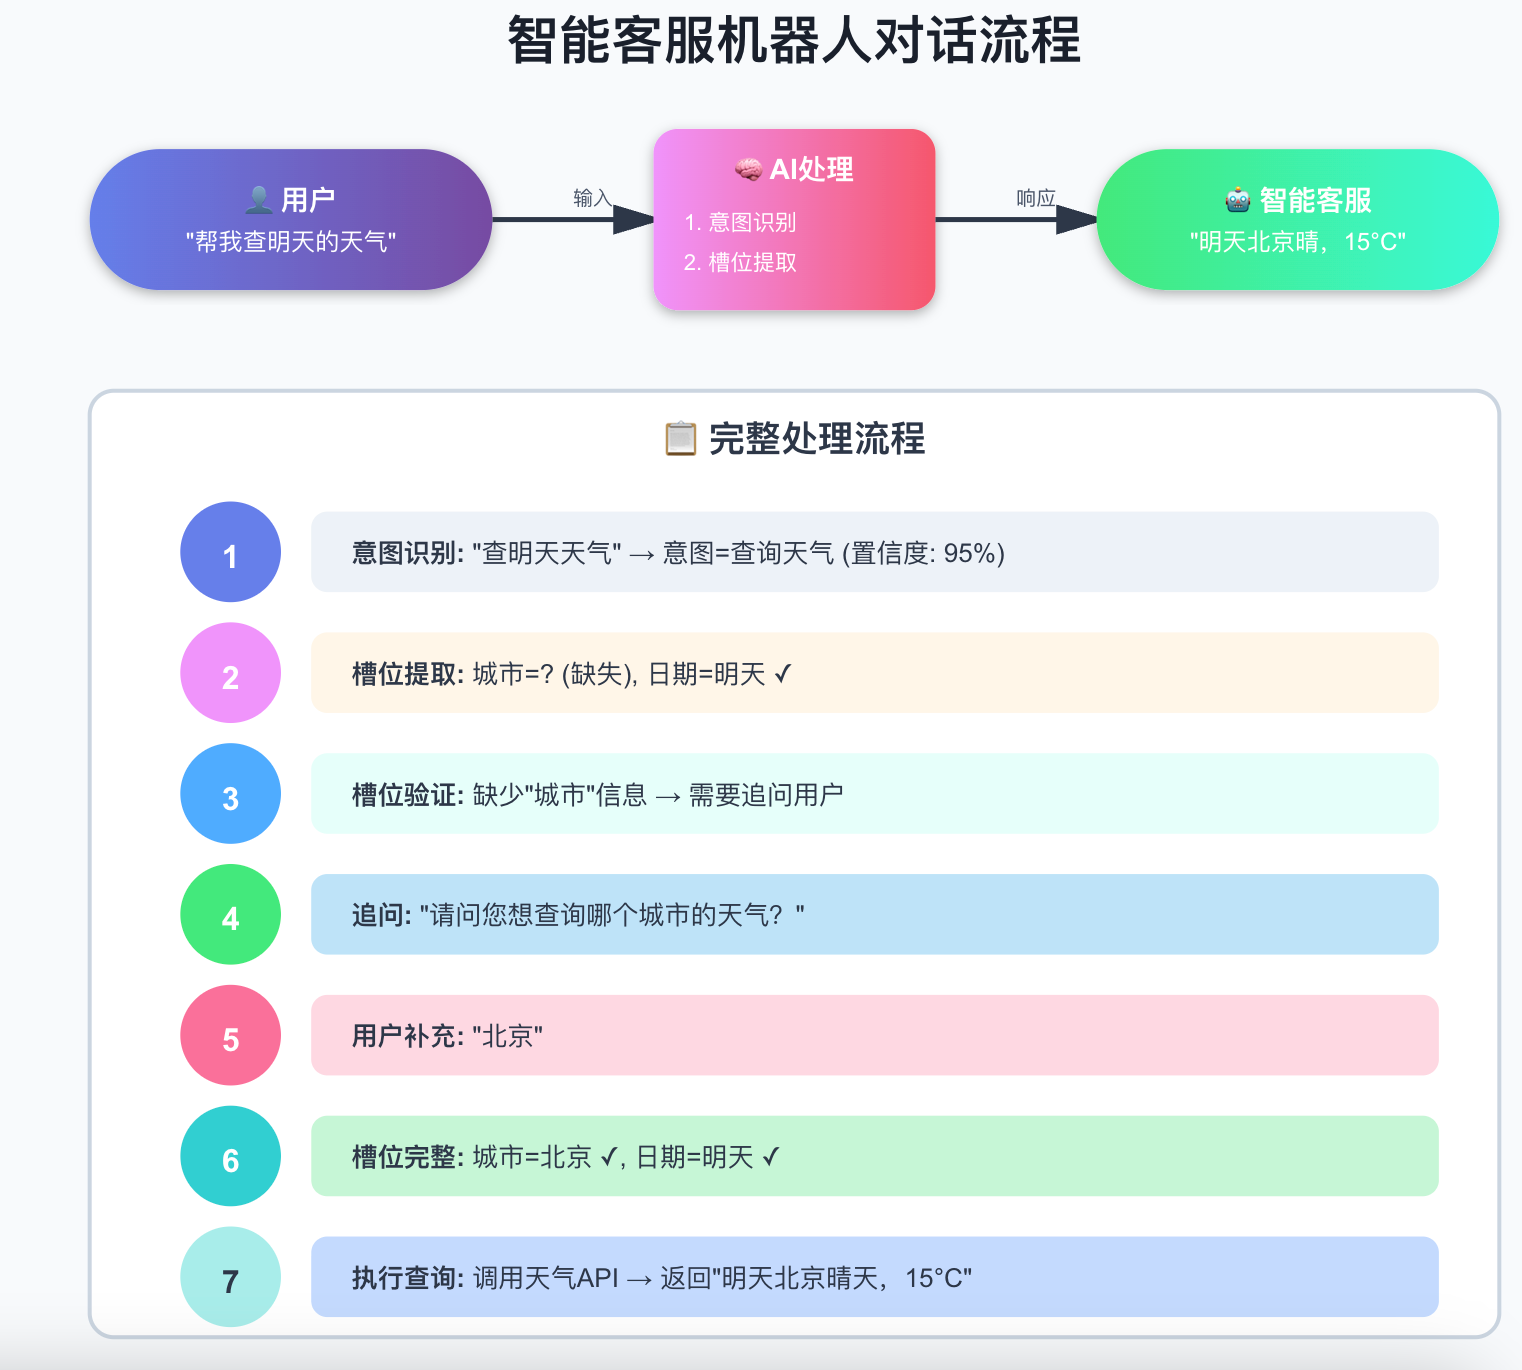

考虑下面的对话：

~~~text
用户：帮我订2张从上海到北京的票。
客服：是哪一天？
用户：明天。
~~~

如果把“明天”当成一个独立分类任务，系统很可能不知道用户想干什么。正确处理依赖上一轮保留下来的状态：

~~~json
{
  "intent": "booking",
  "slots": {
    "departure": "上海",
    "destination": "北京",
    "quantity": 2
  },
  "missing_slots": ["date"]
}
~~~

第二轮只需要解析日期，再与已有槽位合并。历史消息用于追溯过程，结构化状态用于驱动程序；两者作用不同。

对话状态应按用户和会话隔离。任务完成或取消时，清理待补充状态；确实需要延续的对象，例如最近查询的订单号，可以单独保存。

## 先实现演示业务，明确哪些是模拟结果

为了让多轮流程可以直接验证，下面使用固定数据，不连接天气、支付或客服系统。所有业务输出都注明“演示”。

~~~python
DEMO_ORDERS = {
    "ORD123456": {
        "user_id": "u_001",
        "status": "运输中",
        "location": "北京分拨中心",
    }
}

def demo_dispatch(intent, slots, user_id):
    if intent == "greeting":
        return "您好，可以查询天气、订单，或演示订票、退款和转人工流程。"

    if intent == "weather":
        return (
            f"【演示】已收集 {slots['city']}、{slots['date']}；"
            "下一步调用天气 API，此处不提供真实天气。"
        )

    if intent == "booking":
        return (
            f"【演示】待确认行程：{slots['departure']}→{slots['destination']}，"
            f"{slots['date']}，{slots['quantity']}张；尚未创建真实订单。"
        )

    if intent in {"order", "refund"}:
        order = DEMO_ORDERS.get(slots["order_id"])
        if order is None or order["user_id"] != user_id:
            return "【演示】没有找到当前用户可访问的这笔订单。"
        if intent == "refund":
            return f"【演示】已定位订单 {slots['order_id']}；下一步收集原因并校验退款资格。"
        return f"【演示】{slots['order_id']}：{order['status']}，位于{order['location']}。"

    if intent == "human":
        return "【演示】已进入转人工分支；实际排队信息需由客服服务返回。"

    return "暂不支持这项业务。"
~~~

`user_id` 来自应用的登录上下文，不由用户文本或模型随意指定。这里即使是演示字典，也保留了用户范围检查。

业务工具接入后，用真实工具结果替换对应分支。收集完订票信息仍然只是进入后续流程，不能直接声称支付或出票成功。

## 写一个能够连续对话的客服类

下面的类把前面几个模块接起来。`pending` 保存未完成的请求，`last_order_id` 支持同一会话中继续追问物流。

~~~python
class DemoServiceBot:
    def __init__(self, user_id="u_001", today=None):
        self.user_id = user_id
        self.today = today or date.today()
        self.pending = None
        self.last_order_id = None
        self.history = []

    def chat(self, text):
        text = normalize_text(text)["normalized"]
        if not text:
            return "请输入要咨询的问题。"

        if text in {"取消", "取消本次操作", "重新开始"}:
            self.pending = None
            self.last_order_id = None
            reply = "已清空本次任务状态。"
        else:
            active = self.pending or {}
            active_intent = active.get("intent")
            known = dict(active.get("slots", {}))
            missing = active.get("missing_slots", [])

            # 仅在明确追问上一笔物流时，继承最近订单号。
            if not active and self.last_order_id and re.fullmatch(
                r"什么时候能到[？?]?|到哪了[？?]?", text
            ):
                active_intent = "order"
                known = {"order_id": self.last_order_id}

            result = analyze_request(
                text, self.today,
                active_intent=active_intent,
                known_slots=known,
                expected_slot=missing[0] if missing else None,
            )

            if result["status"] == "incomplete":
                self.pending = result
                reply = result["message"]
            elif result["status"] == "uncertain":
                reply = result["message"]
            else:
                self.pending = None
                reply = demo_dispatch(result["intent"], result["slots"], self.user_id)
                if result["intent"] == "order":
                    self.last_order_id = result["slots"]["order_id"]

        self.history.append({"user": text, "assistant": reply})
        self.history = self.history[-20:]
        return reply
~~~

这段代码最重要的是把 `active_intent`、`known_slots`、`expected_slot` 重新传入引擎。状态不仅被保存，还真正参与了下一轮处理。

当前示例支持有限表达与一个待办任务。生产系统还需要处理状态过期、并发消息、业务失败后的恢复，以及用户修改已确认信息的情况。

## 按顺序跑一遍，观察状态如何变化

把本章的规则、槽位、引擎与客服代码依次放到 Python 文件或代码单元中，即可运行下面的演示。此处不需要安装模型库。

~~~python
bot = DemoServiceBot(today=date(2026, 9, 16))

messages = [
    "帮我订2张从上海到北京的票",
    "明天",
    "查一下订单",
    "ORD123456",
    "什么时候能到？",
    "转人工客服",
]
for message in messages:
    print("用户：", message)
    print("客服：", bot.chat(message))
~~~

前四轮的关键结果应为：

~~~text
用户：帮我订2张从上海到北京的票
客服：是哪一天？可以说今天、明天，或填写 YYYY-MM-DD。

用户：明天
客服：【演示】待确认行程：上海→北京，2026-09-17，2张；尚未创建真实订单。

用户：查一下订单
客服：请提供订单号，例如 ORD123456。

用户：ORD123456
客服：【演示】ORD123456：运输中，位于北京分拨中心。
~~~

追问“什么时候能到”时，演示数据只有当前位置，系统仍只返回已知状态。真实实现需要物流工具提供预计送达时间，不能根据“运输中”编出具体日期。

可以继续尝试“明天天气怎么样”之后回复“北京”，或“帮我订票”之后按提示依次补齐参数。这些例子验证的是跨轮补参能力。

## 多意图：拆开任务，也保留任务之间的关系

用户可能一次提出多个要求：“查一下明天北京的天气，然后订一张去上海的票。”

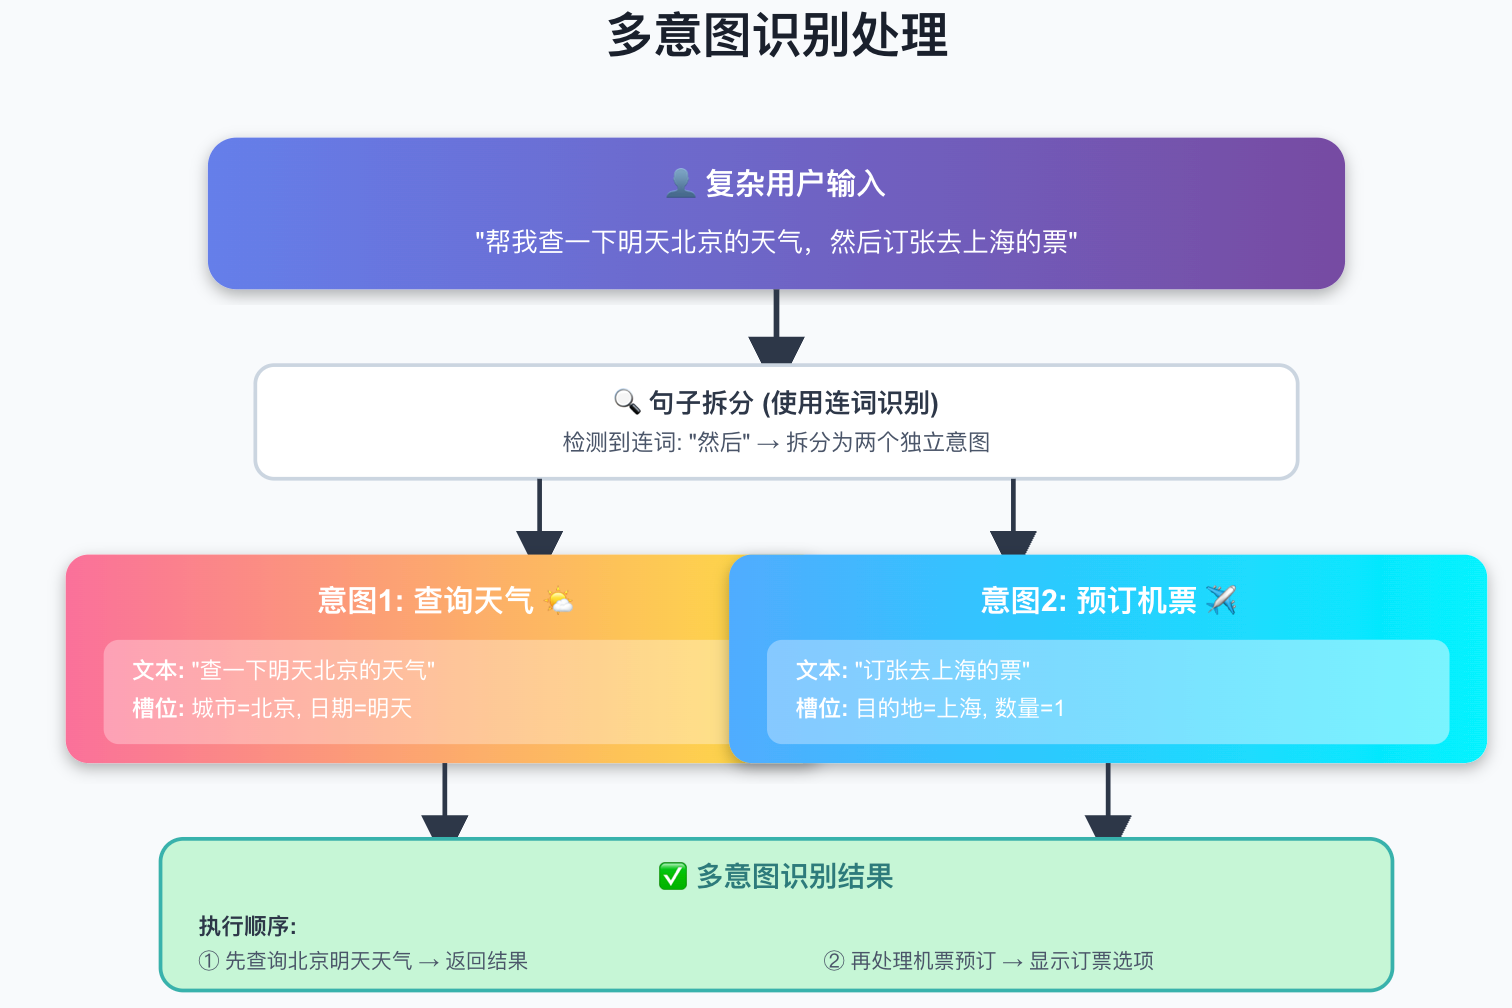

这时应该得到两个任务，而不是强行选择一个标签：

~~~json
{
  "tasks": [
    {
      "id": "weather_1",
      "intent": "weather",
      "slots": {"city": "北京", "date": "2026-09-17"},
      "depends_on": []
    },
    {
      "id": "booking_1",
      "intent": "booking",
      "slots": {"destination": "上海", "quantity": 1},
      "depends_on": ["weather_1"]
    }
  ]
}
~~~

示例按用户说的“然后”保留顺序。它没有擅自把天气查询的“北京、明天”复制成订票的“出发地、日期”；这些信息需要从上下文确认。

原文使用连接词切句。作为初步规则，可以优先识别“然后、另外、接着”等明显边界：

~~~python
def split_candidate_tasks(text):
    return [
        part.strip(" ，。；,;")
        for part in re.split(r"然后|接着|另外|还有", text)
        if part.strip(" ，。；,;")
    ]
~~~

不要遇到每个“和”就切开。“北京和上海的天气”通常是一个意图包含两个城市；“和平区”里的“和”更不是任务边界。

分句只是候选步骤，还需要确认每个片段能否独立构成任务。多意图系统应分别保存各任务的槽位、状态和依赖，不能让一份全局槽位字典互相覆盖。

## 置信度：分数如何影响下一步

识别结果存在不确定性时，可以按分数采取不同处理方式。原文使用了高、中、低三个区间：

| 分数区间示例 | 处理方式 | 对话例子 |
| --- | --- | --- |
| ≥ 0.85 | 继续参数校验与后续流程 | 已识别订单查询，检查订单号 |
| 0.60～0.85 | 询问确认 | “你是想查询订单状态吗？” |
| 0.30～0.60 | 提供少量可能选项 | “是查询物流，还是申请退款？” |
| < 0.30 | 暂不分类，请用户补充 | “请再说明一下要办理的事情。” |

这些数字是策略示例，必须根据模型、数据和业务验证。对不同意图也可以使用不同阈值。

~~~python
def route_by_score(score):
    if not 0 <= score <= 1:
        raise ValueError("score 必须位于 0 到 1 之间")
    if score >= 0.85:
        return "validate_slots"
    if score >= 0.60:
        return "confirm_intent"
    if score >= 0.30:
        return "offer_candidates"
    return "clarify"
~~~

高分不能跳过必填字段和权限检查，也不代表用户已经确认执行某项业务操作。它只影响“如何处理识别结果”。

## 阈值分流不等于概率校准

前面的函数是**策略分流**：按一个分数选择下一步。**概率校准**则是在检查这个分数是否能代表真实正确率。

例如，把分数约为 0.8 的预测放在一起，如果其中大约 80% 正确，才可以说这个区间的分数比较可信。如果只有 50% 正确，模型就过于自信。

常见方法包括在独立验证数据上进行温度缩放、Platt scaling 或 isotonic regression。深度分类器的温度缩放通常调整 logits 的尺度，尽量改善概率解释，而不是重新学习所有模型参数。

校准数据不能与最终测试数据混用。上线后数据分布改变，原来适用的阈值和校准结果也可能失效。

对于大模型自己写出的“confidence: 0.95”，同样需要通过标注任务检验，不能直接把这句话当作客观概率。

## 准确率不高时，先检查数据与意图边界

| 现象 | 常见原因 | 改进方向 |
| --- | --- | --- |
| 只会识别固定说法 | 表达覆盖不足 | 增加口语、同义词、错别字和省略表达 |
| 两个类别经常混淆 | 标注定义重叠 | 明确类别边界，补充相邻类别样本 |
| 短句识别不好 | 缺少上一轮任务信息 | 将当前意图和待填字段接入识别 |
| 总是预测常见类别 | 类别分布不均衡 | 检查各类样本和单类召回率 |
| 离线很好，上线很差 | 测试集过于相似或发生数据变化 | 使用真实时间段与独立会话进行验证 |

同义改写可以增加表达覆盖。例如“查询天气”可以改成“查看天气”“看看天气”。但改写后仍应检查语义，尤其是“不想退”“取消订单”等容易改变意图的句子。

先把原始样本按用户、会话或来源划分，再只增强训练集。若把同一句话的几个近似改写分到训练集和测试集，测试分数会显得过于乐观。

业务范围外的输入也需要样本。没有“无法识别”或拒识策略，分类器可能把任何文本都塞进已知类别。

## 模型持久化与真正的批量推理

训练完成后应保存模型，服务启动时加载一次，不必每次请求都重新训练。传统机器学习可以保存完整 Pipeline：

~~~python
import joblib

# 在训练和验证完成后执行：
# joblib.dump(intent_model, "intent_model.joblib")
# loaded_model = joblib.load("intent_model.joblib")
~~~

同时记录库版本、标签定义、预处理方式和训练数据版本。`joblib`、`pickle` 文件只应从可信来源加载，因为反序列化并不是纯粹读取无害文本。

前面的字符 n-gram Pipeline 没有使用匿名 tokenizer 函数，也更方便持久化。若使用自定义分词函数，应将其定义在可导入的模块中。

批量推理要把一批文本真正送入模型，而不是在一个批次里仍然逐条调用：

~~~python
def batched_predict(model, texts, batch_size=32):
    if batch_size < 1:
        raise ValueError("batch_size 必须为正数")
    results = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        results.extend(predict_intents(model, batch))
    return results
~~~

BERT 同理：一批文本一起 tokenizer，再执行一次模型前向传播。批次越大不一定越好，还要考虑显存、最长文本和响应时间。

## 评估：不仅看“猜对了多少句”

准确率是预测正确的样本比例，但在类别不平衡时容易掩盖问题。例如绝大多数请求都是天气查询，模型即使几乎不会识别退款，总体准确率仍可能不低。

| 指标 | 含义 | 适合发现什么问题 |
| --- | --- | --- |
| Accuracy | 全部样本中预测正确的比例 | 整体分类情况 |
| Precision，精确率 | 预测为某类的样本中有多少真属于该类 | 错把其他请求当成该类 |
| Recall，召回率 | 真属于某类的样本中有多少被找到 | 漏掉该类请求 |
| F1 | 精确率和召回率的调和平均 | 同时衡量误报与漏报 |
| Macro-F1 | 每个类别的 F1 等权平均 | 小类别是否被忽视 |
| 混淆矩阵 | 真实类别与预测类别的交叉计数 | 哪两个意图最容易混淆 |

用前面保留的测试集，可以生成分类报告：

~~~python
from sklearn.metrics import classification_report, confusion_matrix

predictions = intent_model.predict(test_x)
print(classification_report(test_y, predictions, zero_division=0))

label_order = list(intent_model.classes_)
matrix = confusion_matrix(test_y, predictions, labels=label_order)
print("行是真实标签，列是预测标签：", label_order)
print(matrix)
~~~

这个小测试集只用于演示评估接口。正式结果应说明测试样本量、类别分布、数据时间和与训练数据的隔离方式。

## 从分类正确走到任务完成

意图识别只是整个 Agent 的一个环节。识别成“订票”后，如果日期提错、跨轮丢失出发地，任务仍然无法完成。

因此还要检查：

- **槽位准确性：** 城市、日期、数量和订单号是否正确，必填字段是否全部匹配。
- **多轮完成率：** 用户按追问补充信息后，能否继续原任务。
- **澄清质量：** 是否问到了真正缺少的信息，是否反复问已经回答过的内容。
- **工具与业务结果：** 是否调用正确工具，是否符合业务规则，是否完成真实操作。
- **运行成本：** 延迟、模型调用次数、费用、失败与转人工情况。

可以从本手册的三个小实验开始练习：跟踪计算器的两轮执行；测试客服如何补齐订票和订单信息；把分类器换成 TF-IDF 模型，再比较意图分类与多轮任务完成的差别。

阅读代码时始终跟踪三样东西：**现在保存了什么状态、下一步依据什么执行、得到什么证据才算完成。**

## 资料来源

本笔记依据 [《大模型 AI Agent 知识从 0–1 笔记》](https://dqej47nflyz.feishu.cn/wiki/CkzZwmDPbiUvP5kVyiIcVQepnEf) 整理，覆盖 Agent 主体内容及意图识别补充部分。图片来自原手册，表格按知识点重新编排；示例补充了数据流说明，并修正部分不完整或容易误用的写法。

原图中的模型版本、框架接口、示例分数与历史时间用于理解原文，不作为当前性能或价格承诺。代码以阅读和分段练习为主，涉及外部库、模型权重与业务 API 的部分，需在对应环境准备好后运行。